<a id="libraries"></a>
 <h1 style="text-align:center;">
       <b><span style="color:#800000">First Notebook</span></b>
</h1>


<a id="libraries"></a>
# <b><span style='color:#0000FF'>A Comparative Analysis: </span><span style='color:#0000FF'> Machine Learning vs. Statistical Models</span></b>

## Part 1: Regression Analysis

#### 🎯 Objective
This notebook provides a comparative analysis of two different approaches to linear regression:

- The **Machine Learning (ML) approach** `(Scikit-learn Linear Regression)`, focused on predictive accuracy (using scikit-learn).

- The **Statistical Modeling approach**`(OLS Regression)`, focused on inference and model diagnostics (using statsmodels).


#### 📦 Datasets
We will use three standard regression datasets to conduct this comparison:

- **California Housing:** A high-dimensional dataset used for predicting housing prices.

- **Diabetes:** A classic, smaller dataset for predicting disease progression.

- **Wine Quality:** A dataset used to predict the quality of wine based on physicochemical tests.

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #FFFFFF; font-size:130%; text-align:left">

<h2 align="left"><font color=#6a7f7a>Table of Contents:</font></h2>
    
* [Step 1 | Importing Necessary Libraries](#libraries)
   
* [Step 2 | Exploratory Data Analysis (EDA) for all  📦 Datasets ](#eda) 
    - [Step 2.1 | EDA for California Housing Dataset](#eda1) 
    - [Step 2.2 | EDA for  Diabetes Dataset](#eda2)
    - [Step 2.3 | EDA for Wine Quality Dataset](#eda3) 
    
* [Step 3 |  Data Preprocessing ](#DP) 
    - [Step 3.1 | 🔧 Data Preprocessing for California Housing Dataset](#DP1) 
    - [Step 3.2 | 🔧 Data Preprocessing for Diabetes Dataset](#DP2)
    - [Step 3.3 | 🔧 Data Preprocessing for Wine Quality Dataset](#DP3) 
    
* [Step 4 |  Model Training, Evaluation, and Comparison ](#Ml) 
    - [Step 4.1 |  CALIFORNIA HOUSING](#Ml1) 
    - [Step 4.2 |  DIABETES](#Ml2)
    - [Step 4.3 | WINE QUALITY](#Ml3)
    
* [Step 5 | COMPREHENSIVE GENERAL COMPARISON and CONCLUSION ](#Cg) 


<a id="libraries"></a>
# <b><span style='color:#09ba80'>Step 1 |</span><span style='color:#34e3ae'> Importing Necessary Libraries</span></b>
- This section imports all necessary packages, groups them by function, and loads the datasets we will use for the analysis.
⬆️ [Tabel of Contents](#contents_tabel)

In [45]:
# Import necessary libraries

import numpy as np #The fundamental package for numerical computing in Python.
import pandas as pd # A library for high-performance, easy-to-use data structures and data analysis.
import matplotlib.pyplot as plt #The primary library for creating static, animated, and interactive visualizations.
import seaborn as sns # A high-level data visualization library based on matplotlib, providing attractive statistical graphics.
import time # A library that provides classes and functions for the estimation of many different statistical models

# Warnings: Used to control how warning messages are handled (we will ignore them for cleaner output).
import warnings
warnings.filterwarnings('ignore')


# --- Machine Learning (Scikit-learn) Libraries ---
from sklearn.model_selection import train_test_split # Contains tools for splitting data into training and test sets.
from sklearn.preprocessing import StandardScaler, RobustScaler # Includes modules for scaling and transforming features.
from sklearn.linear_model import LinearRegression # Contains the scikit-learn implementation of Linear Regression.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error # Used to evaluate model performance



# --- Statistical Modeling (Statsmodels) Library ---
import statsmodels.api as sm # A library that provides classes and functions for the estimation of many different statistical models.
from scipy import stats# A module containing a large number of probability distributions and statistical functions.

<a id="eda"></a>
# <b><span style='color:#09ba80'>Step 2 | </span><span style='color:#34e3ae'>Exploratory Data Analysis (EDA) for all  📦 Datasets  </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="eda1"></a>
## <b><span style='color:#299617'>Step 2.1 | </span><span style='color:#299617'>EDA for California Housing Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [46]:
# Load dataset
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y  # Target variable

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: MedHouseVal (Median house value in hundreds of thousands of dollars)")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df.describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes)

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Target Variable Analysis:")
print(f"   - Mean: {y.mean():.2f}")
print(f"   - Median: {np.median(y):.2f}")
print(f"   - Std: {y.std():.2f}")
print(f"   - Min: {y.min():.2f}")
print(f"   - Max: {y.max():.2f}")
print(f"   - Skewness: {stats.skew(y):.2f}")
print(f"   - Kurtosis: {stats.kurtosis(y):.2f}")


1. Dataset Overview:
   - Shape: 20640 samples × 9 features (including target)
   - Features: 8
   - Target variable: MedHouseVal (Median house value in hundreds of thousands of dollars)

2. Feature Names:
   1. MedInc
   2. HouseAge
   3. AveRooms
   4. AveBedrms
   5. Population
   6. AveOccup
   7. Latitude
   8. Longitude

3. Basic Statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.2 | </span><span style='color:#800000'>  Visualizations </span></b>

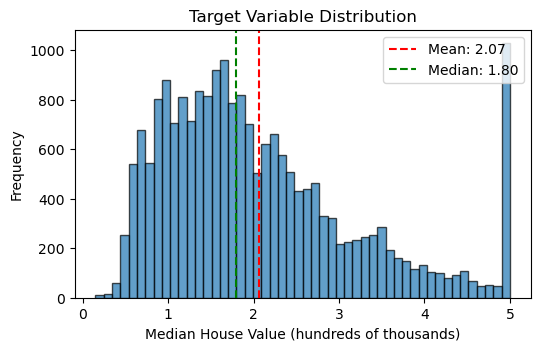

In [47]:
# Visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Target variable distribution
ax1 = plt.subplot(4, 3, 1)
ax1.hist(y, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Median House Value (hundreds of thousands)')
ax1.set_ylabel('Frequency')
ax1.set_title('Target Variable Distribution')
ax1.axvline(y.mean(), color='r', linestyle='--', label=f'Mean: {y.mean():.2f}')
ax1.axvline(np.median(y), color='g', linestyle='--', label=f'Median: {np.median(y):.2f}')
ax1.legend()



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.3 | </span><span style='color:#800000'>  Feature distributions </span></b>

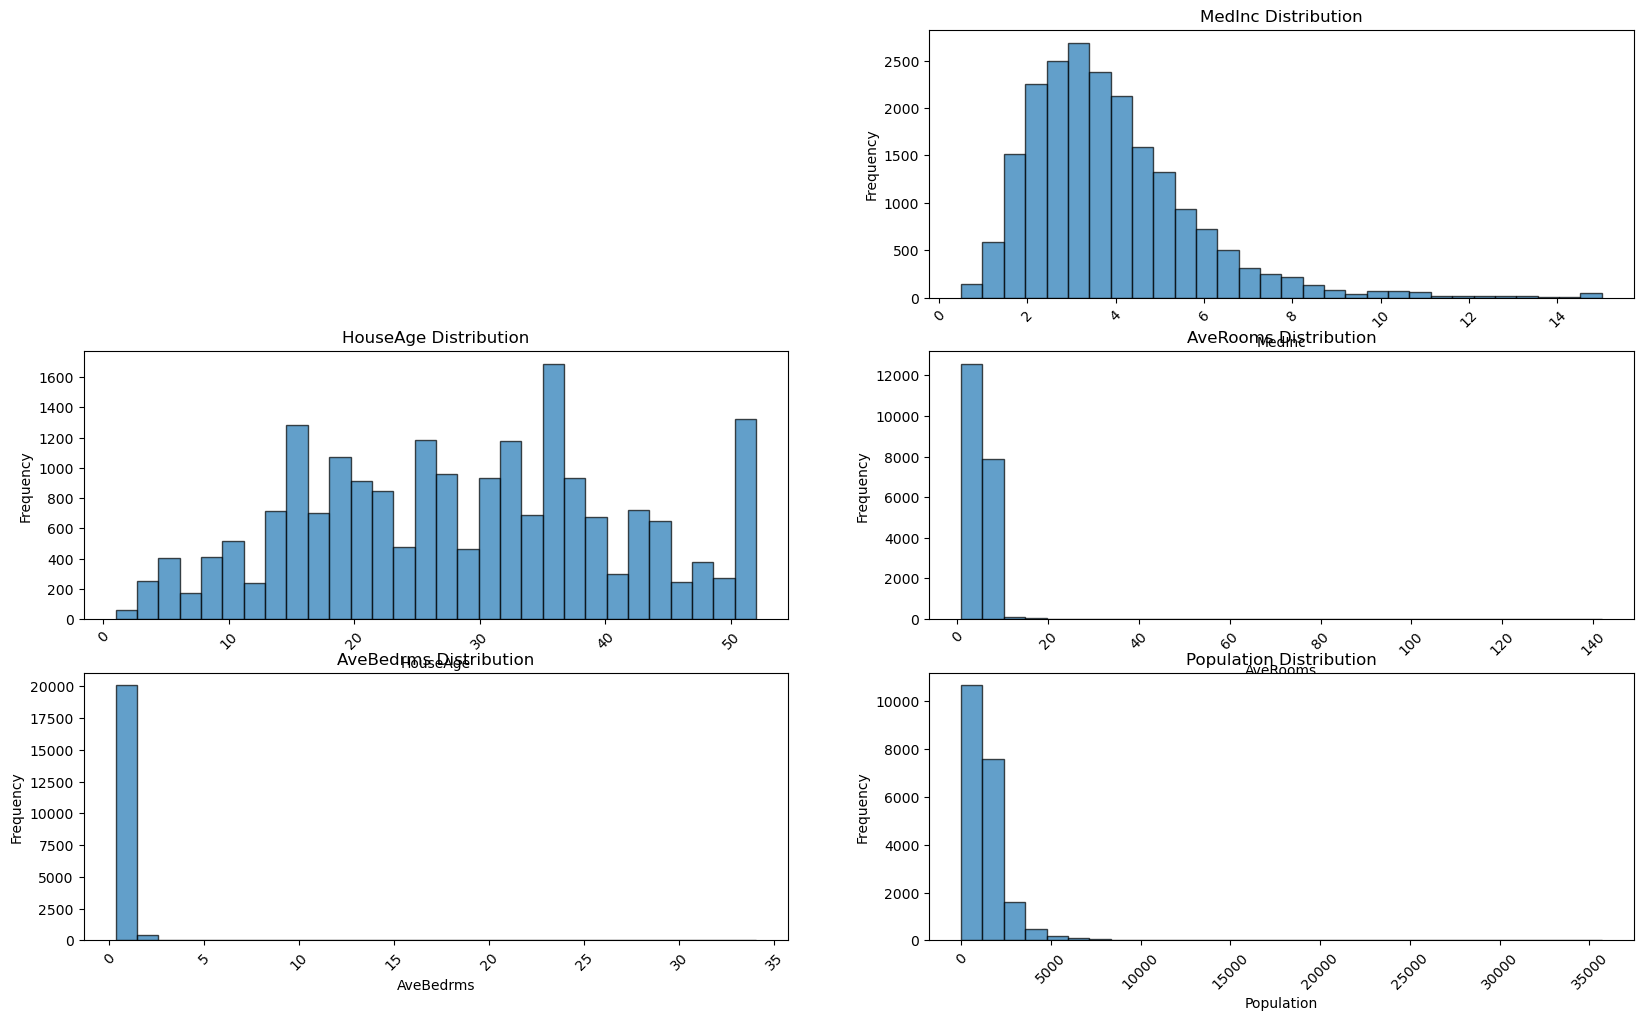

In [48]:
# 2. Feature distributions (5 features)
plt.figure(figsize=(20, 16))
for i, feature in enumerate(feature_names[:5], 2):
    ax = plt.subplot(4, 2, i)
    ax.hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.tick_params(axis='x', rotation=45)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.4 | </span><span style='color:#800000'>   Correlation matrix </span></b>

Text(0.5, 1.0, 'Correlation Matrix')

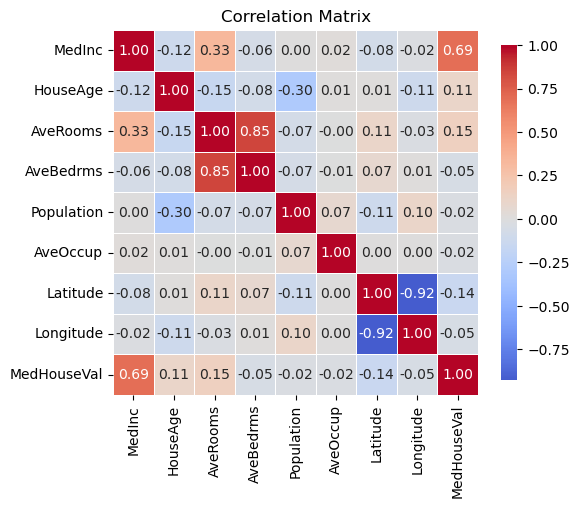

In [49]:
plt.figure(figsize=(20, 25))
ax7 = plt.subplot(4, 3, 7)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax7)
ax7.set_title('Correlation Matrix')



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.5 | </span><span style='color:#800000'>  Target vs Features (scatter plots for top correlated features) </span></b>

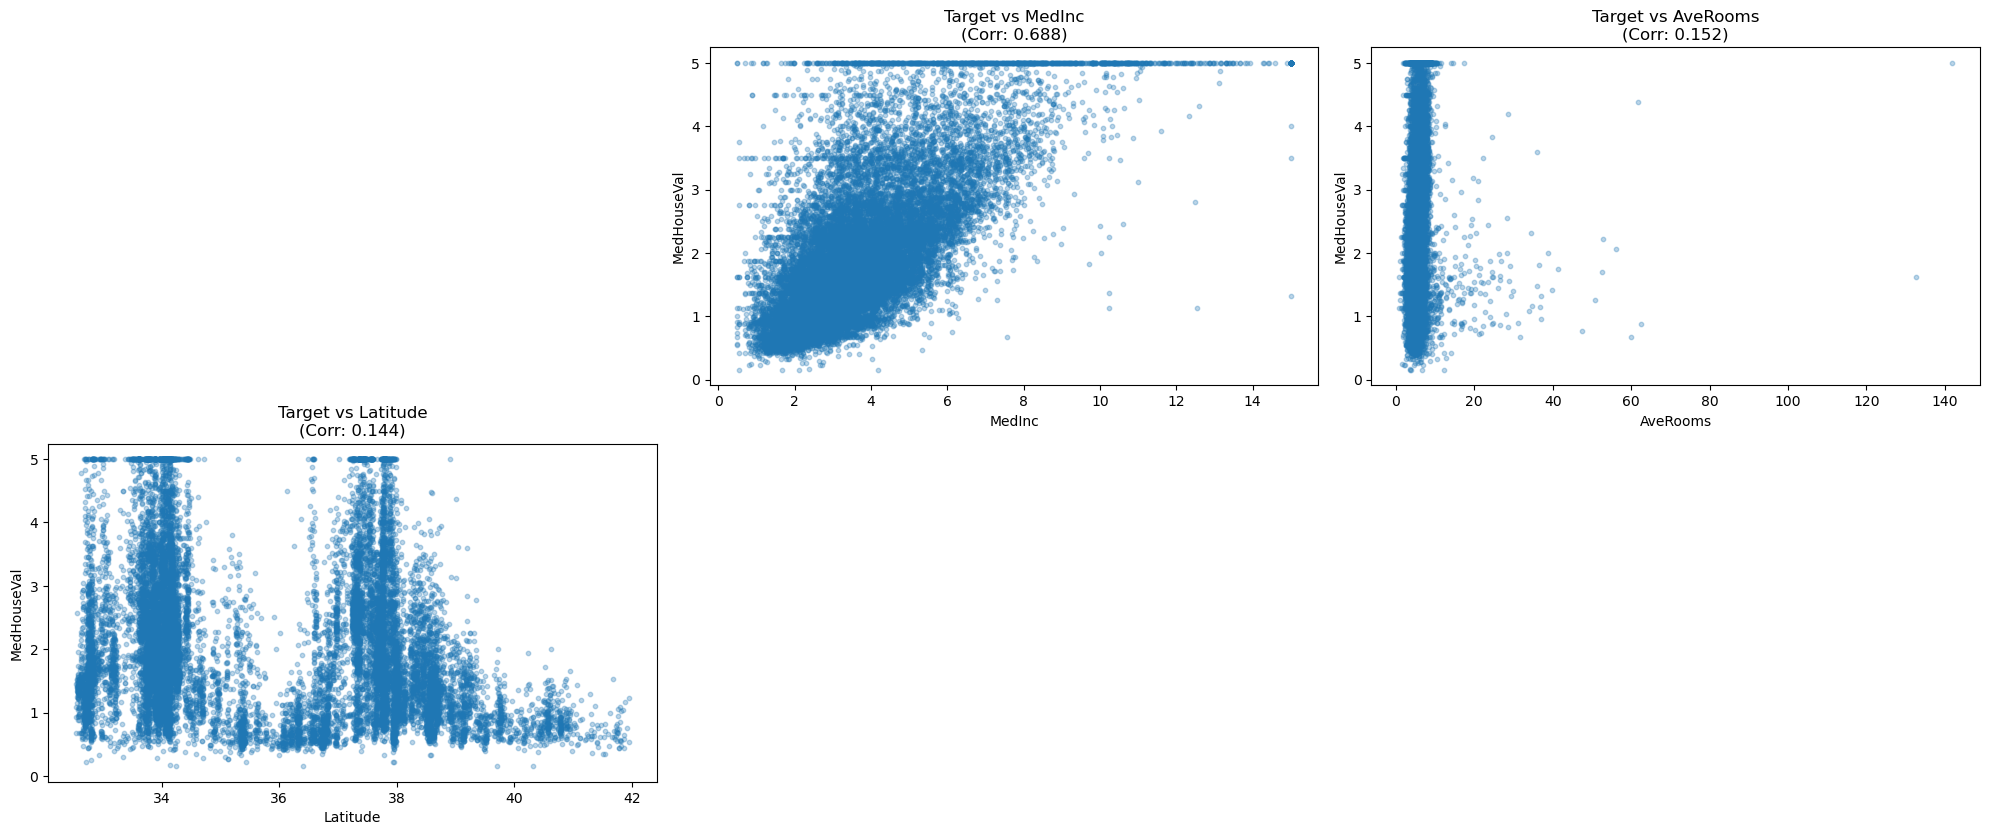

In [51]:
# Get top 3 features correlated with target
target_corr = df.corr()['MedHouseVal'].abs().sort_values(ascending=False)
top_features = target_corr.index[1:4]  # Exclude target itself
plt.figure(figsize=(20, 16))
for idx, feature in enumerate(top_features, 8):
    ax = plt.subplot(4, 3, idx)
    ax.scatter(df[feature], y, alpha=0.3, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'Target vs {feature}\n(Corr: {target_corr[feature]:.3f})')

plt.tight_layout()
plt.show()


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.6 | </span><span style='color:#800000'>  Features Correlated - Outlier </span></b>

In [52]:
print(f"\n7. Top Features Correlated with Target:")
for feature in top_features:
    corr_val = target_corr[feature]
    print(f"   - {feature}: {corr_val:.3f}")

print(f"\n8. Outlier Detection (IQR method):")
outliers_summary = {}
for feature in feature_names:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
        outliers_summary[feature] = outliers
        if outliers > 0:
            print(f"   - {feature}: {outliers} outliers ({100*outliers/len(df):.1f}%)")

print("\n✅ California Housing EDA Complete!")
print("=" * 80)


7. Top Features Correlated with Target:
   - MedInc: 0.688
   - AveRooms: 0.152
   - Latitude: 0.144

8. Outlier Detection (IQR method):
   - MedInc: 681 outliers (3.3%)
   - AveRooms: 511 outliers (2.5%)
   - AveBedrms: 1424 outliers (6.9%)
   - Population: 1196 outliers (5.8%)
   - AveOccup: 711 outliers (3.4%)

✅ California Housing EDA Complete!


<a id="eda2"></a>
## <b><span style='color:#299617'>Step 2.2 | </span><span style='color:#299617'>EDA for  Diabetes Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [55]:
# Load dataset
from sklearn.datasets import load_diabetes
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names


# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y  # Target variable (disease progression)

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: Disease progression (quantitative measure)")
print(f"   - Note: All features are standardized (mean=0, std=1)")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df.describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes)

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Target Variable Analysis:")
print(f"   - Mean: {y.mean():.2f}")
print(f"   - Median: {np.median(y):.2f}")
print(f"   - Std: {y.std():.2f}")
print(f"   - Min: {y.min():.2f}")
print(f"   - Max: {y.max():.2f}")
print(f"   - Skewness: {stats.skew(y):.2f}")
print(f"   - Kurtosis: {stats.kurtosis(y):.2f}")



1. Dataset Overview:
   - Shape: 442 samples × 11 features (including target)
   - Features: 10
   - Target variable: Disease progression (quantitative measure)
   - Note: All features are standardized (mean=0, std=1)

2. Feature Names:
   1. age
   2. sex
   3. bmi
   4. bp
   5. s1
   6. s2
   7. s3
   8. s4
   9. s5
   10. s6

3. Basic Statistics:
          age     sex     bmi      bp      s1      s2      s3      s4      s5  \
count  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.00  442.00   
mean    -0.00    0.00   -0.00   -0.00   -0.00    0.00   -0.00   -0.00    0.00   
std      0.05    0.05    0.05    0.05    0.05    0.05    0.05    0.05    0.05   
min     -0.11   -0.04   -0.09   -0.11   -0.13   -0.12   -0.10   -0.08   -0.13   
25%     -0.04   -0.04   -0.03   -0.04   -0.03   -0.03   -0.04   -0.04   -0.03   
50%      0.01   -0.04   -0.01   -0.01   -0.00   -0.00   -0.01   -0.00   -0.00   
75%      0.04    0.05    0.03    0.04    0.03    0.03    0.03    0.03    0.03  

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.2 | </span><span style='color:#800000'>  Visualizations </span></b>

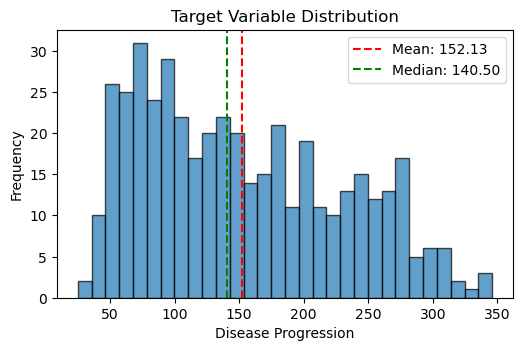

In [56]:
# Visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Target variable distribution
ax1 = plt.subplot(4, 3, 1)
ax1.hist(y, bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Disease Progression')
ax1.set_ylabel('Frequency')
ax1.set_title('Target Variable Distribution')
ax1.axvline(y.mean(), color='r', linestyle='--', label=f'Mean: {y.mean():.2f}')
ax1.axvline(np.median(y), color='g', linestyle='--', label=f'Median: {np.median(y):.2f}')
ax1.legend()


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.3 | </span><span style='color:#800000'>  Feature distributions </span></b>

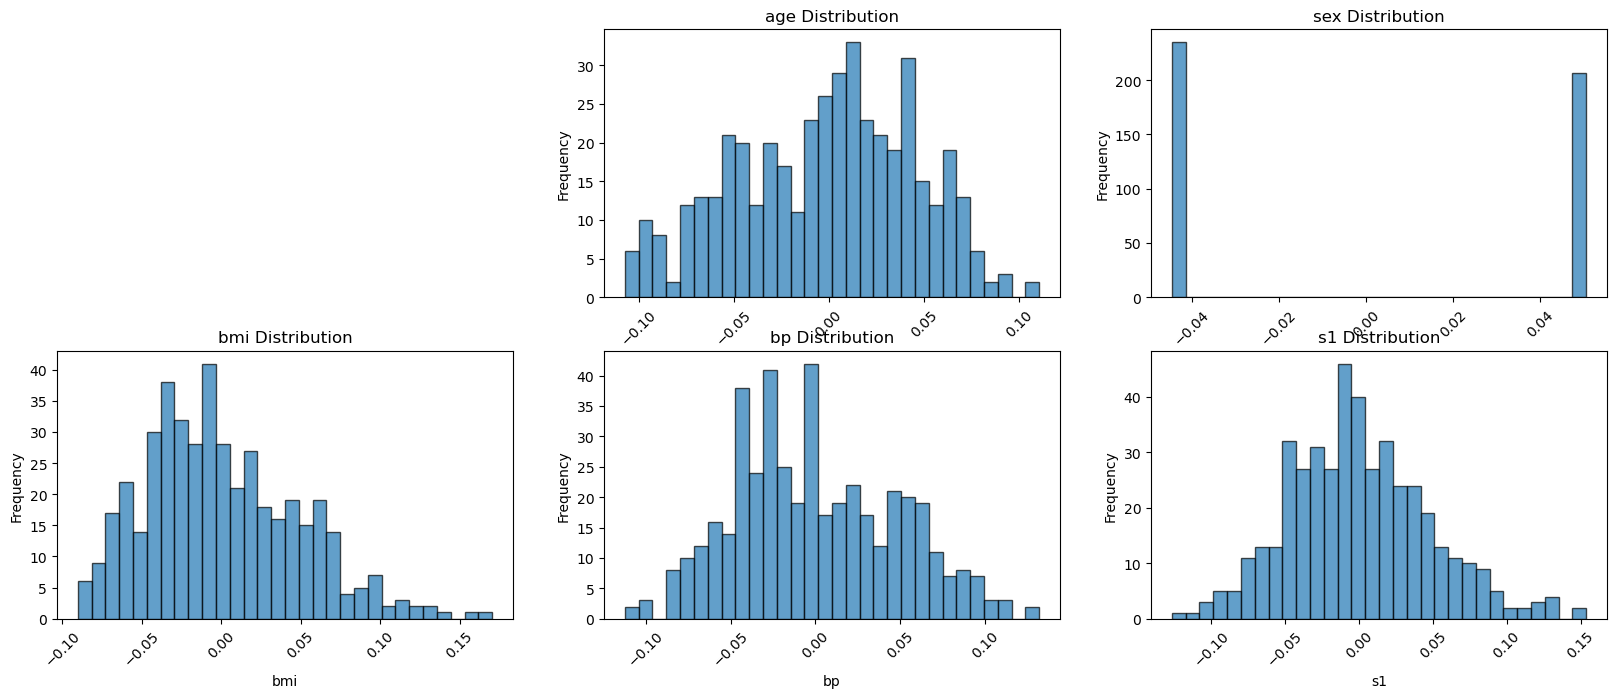

In [57]:
# Feature distributions (5 features)
fig = plt.figure(figsize=(20, 16))
for i, feature in enumerate(feature_names[:5], 2):
    ax = plt.subplot(4, 3, i)
    ax.hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.tick_params(axis='x', rotation=45)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.4 | </span><span style='color:#800000'>   Correlation matrix </span></b>

Text(0.5, 1.0, 'Correlation Matrix')

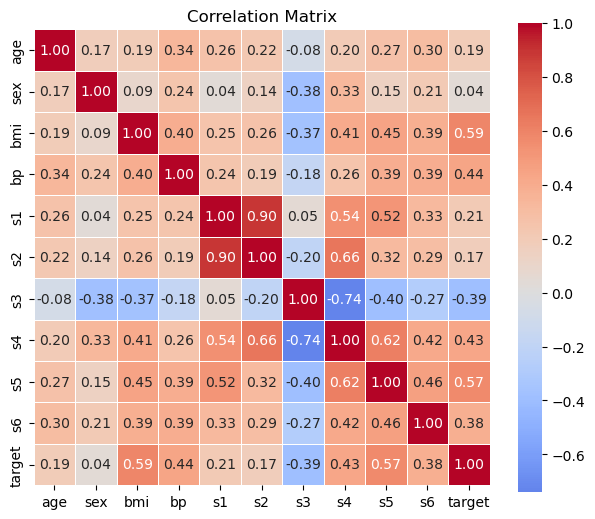

In [62]:
# 3. Correlation matrix
fig = plt.figure(figsize=(25, 35))
ax7 = plt.subplot(4, 3, 7)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax7,
            xticklabels=[name[:8] for name in df.columns], 
            yticklabels=[name[:8] for name in df.columns])
ax7.set_title('Correlation Matrix')


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.5 | </span><span style='color:#800000'>  Target vs Features (scatter plots for top correlated features) </span></b>

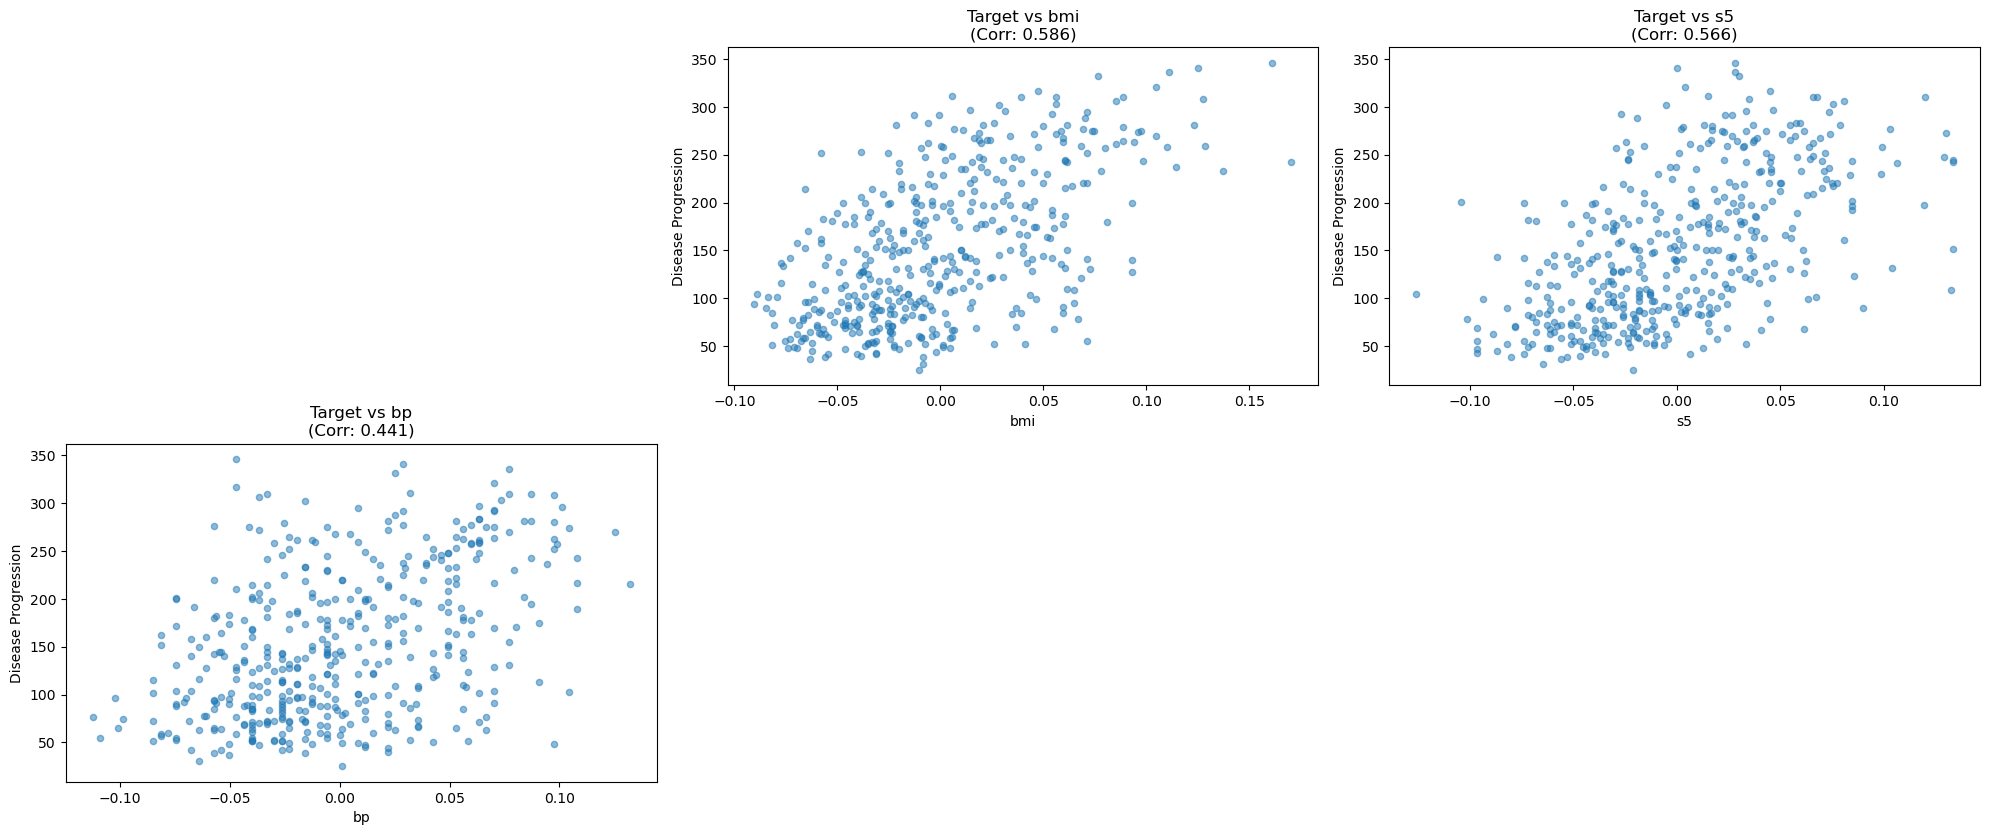

In [63]:

# Target vs Features (scatter plots for top correlated features)
target_corr = df.corr()['target'].abs().sort_values(ascending=False)
top_features = target_corr.index[1:4]  # Exclude target itself
fig = plt.figure(figsize=(20, 16))
for idx, feature in enumerate(top_features, 8):
    ax = plt.subplot(4, 3, idx)
    ax.scatter(df[feature], y, alpha=0.5, s=20)
    ax.set_xlabel(feature)
    ax.set_ylabel('Disease Progression')
    ax.set_title(f'Target vs {feature}\n(Corr: {target_corr[feature]:.3f})')

plt.tight_layout()
plt.show()



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.6 | </span><span style='color:#800000'>  Features Correlated - Outlier </span></b>

In [65]:
print(f"\n7. Top Features Correlated with Target:")
for feature in top_features:
    corr_val = target_corr[feature]
    print(f"   - {feature}: {corr_val:.3f}")

print(f"\n8. Feature Statistics (since features are standardized):")
print(f"   - All features should have mean ≈ 0 and std ≈ 1")
print(f"   - Mean ranges: [{df[feature_names].mean().min():.4f}, {df[feature_names].mean().max():.4f}]")
print(f"   - Std ranges: [{df[feature_names].std().min():.4f}, {df[feature_names].std().max():.4f}]")

print("\n✅ Diabetes EDA Complete!")
print("=" * 80)


7. Top Features Correlated with Target:
   - bmi: 0.586
   - s5: 0.566
   - bp: 0.441

8. Feature Statistics (since features are standardized):
   - All features should have mean ≈ 0 and std ≈ 1
   - Mean ranges: [-0.0000, 0.0000]
   - Std ranges: [0.0476, 0.0476]

✅ Diabetes EDA Complete!


<a id="eda3"></a>
## <b><span style='color:#299617'>Step 2.3 | </span><span style='color:#299617'>EDA for Wine Quality Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [66]:
print("=" * 80)
# Load dataset
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names


# For regression, we'll use alcohol content as target (or create a continuous target)
# Using the alcohol feature as target for regression
alcohol_idx = list(feature_names).index('alcohol')
X_reg = np.delete(X, alcohol_idx, axis=1)
feature_names_reg = [f for i, f in enumerate(feature_names) if i != alcohol_idx]
y_reg = X[:, alcohol_idx]  # Use alcohol content as target

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['alcohol'] = y_reg  # Target variable (alcohol content)

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)} original features")
print(f"   - Target variable: Alcohol content (% by volume)")
print(f"   - Note: Using alcohol content as target for regression task")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df.describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes)

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Target Variable Analysis (Alcohol Content):")
print(f"   - Mean: {y_reg.mean():.2f}%")
print(f"   - Median: {np.median(y_reg):.2f}%")
print(f"   - Std: {y_reg.std():.2f}%")
print(f"   - Min: {y_reg.min():.2f}%")
print(f"   - Max: {y_reg.max():.2f}%")
print(f"   - Skewness: {stats.skew(y_reg):.2f}")
print(f"   - Kurtosis: {stats.kurtosis(y_reg):.2f}")



1. Dataset Overview:
   - Shape: 178 samples × 13 features (including target)
   - Features: 13 original features
   - Target variable: Alcohol content (% by volume)
   - Note: Using alcohol content as target for regression task

2. Feature Names:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline

3. Basic Statistics:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
7

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.2 | </span><span style='color:#800000'>  Visualizations </span></b>

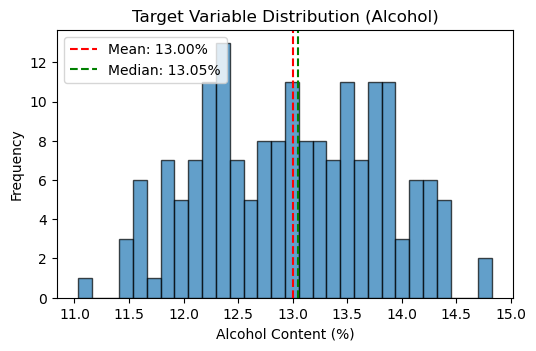

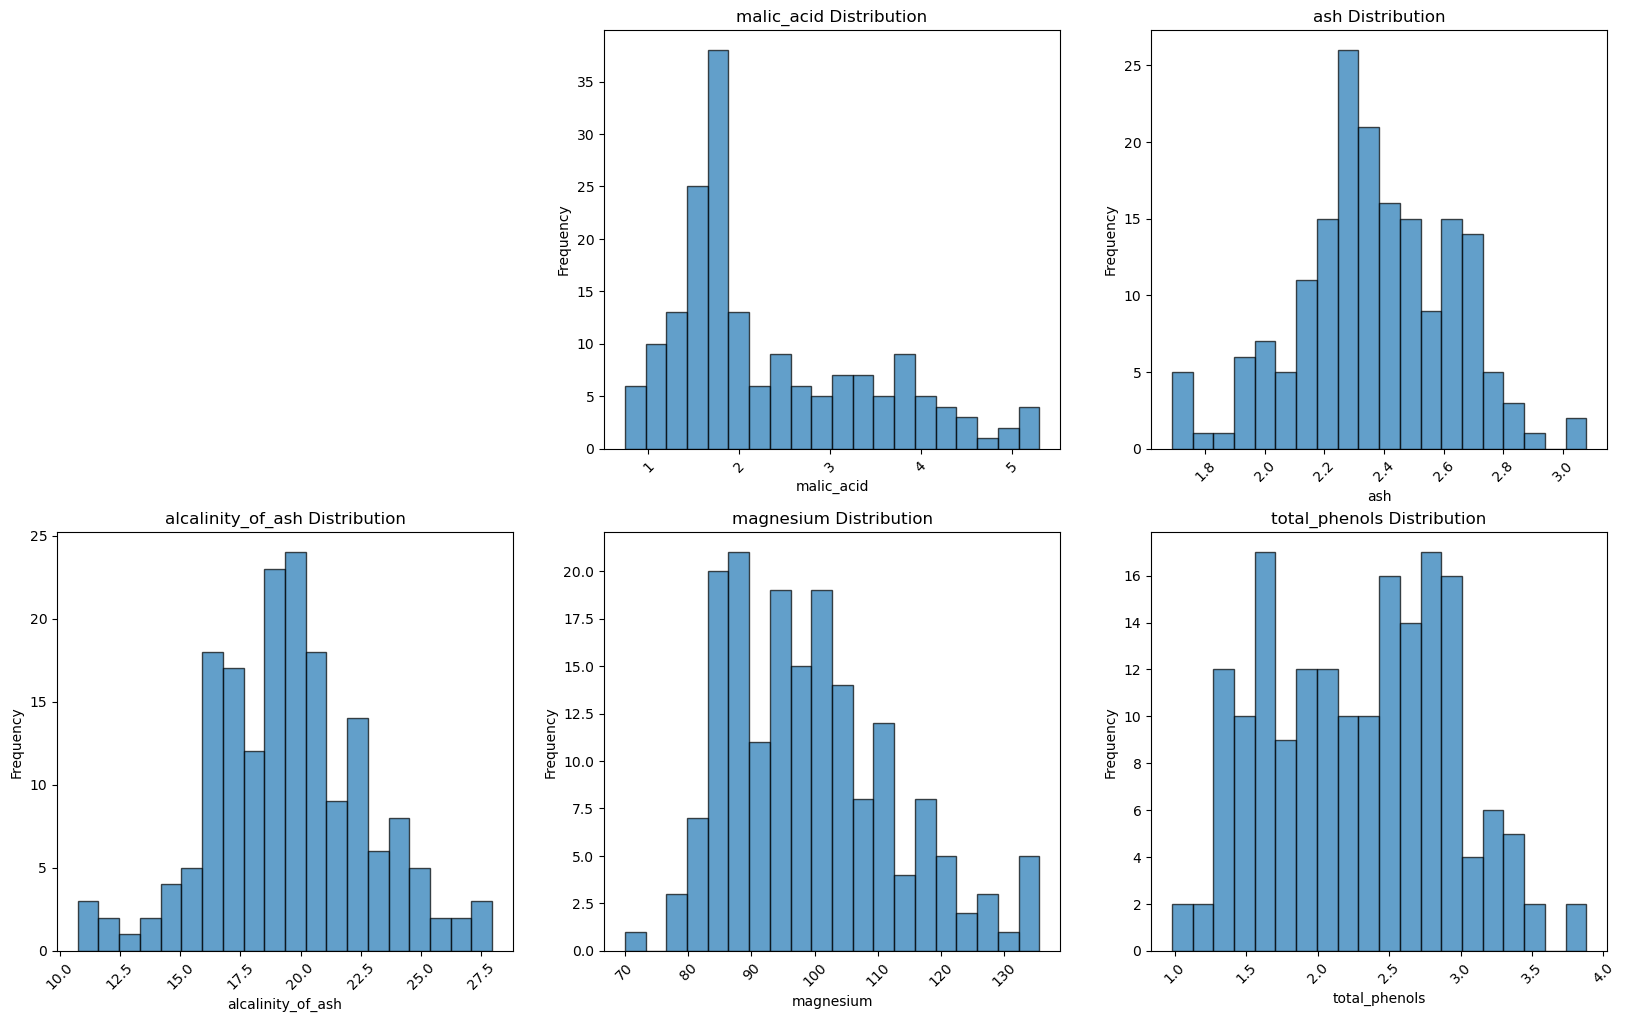

In [89]:

# Visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Target variable distribution
ax1 = plt.subplot(4, 3, 1)
ax1.hist(y_reg, bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Alcohol Content (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Target Variable Distribution (Alcohol)')
ax1.axvline(y_reg.mean(), color='r', linestyle='--', label=f'Mean: {y_reg.mean():.2f}%')
ax1.axvline(np.median(y_reg), color='g', linestyle='--', label=f'Median: {np.median(y_reg):.2f}%')
ax1.legend()

#  Feature distributions (select key wine features - 5 features)
key_features = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']
plot_features = [f for f in key_features if f in df.columns][:5]
fig = plt.figure(figsize=(20, 25))
for i, feature in enumerate(plot_features, 2):
    ax = plt.subplot(4, 3, i)
    ax.hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.tick_params(axis='x', rotation=45)


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.3 | </span><span style='color:#800000'>   Correlation matrix </span></b>

Text(0.5, 1.0, 'Correlation Matrix')

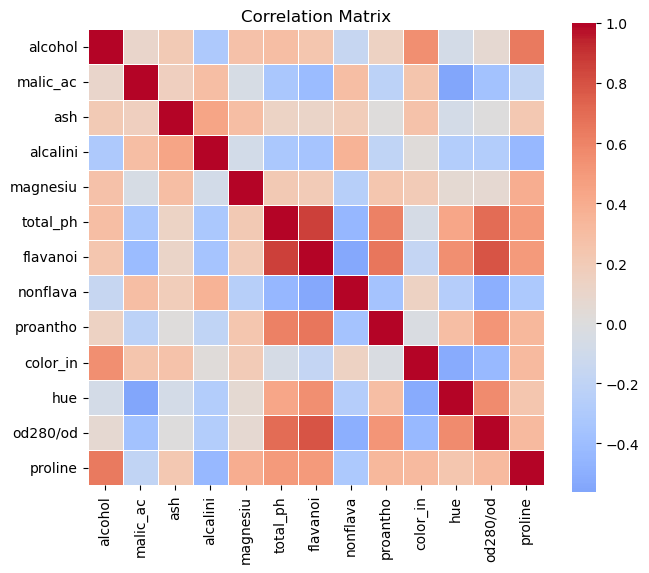

In [74]:
# Correlation matrix
fig = plt.figure(figsize=(25, 35))
ax7 = plt.subplot(4, 3, 7)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax7,
            xticklabels=[name[:8] for name in df.columns], 
            yticklabels=[name[:8] for name in df.columns])
ax7.set_title('Correlation Matrix')



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.4 | </span><span style='color:#800000'>  Target vs Features (scatter plots for top correlated features) </span></b>

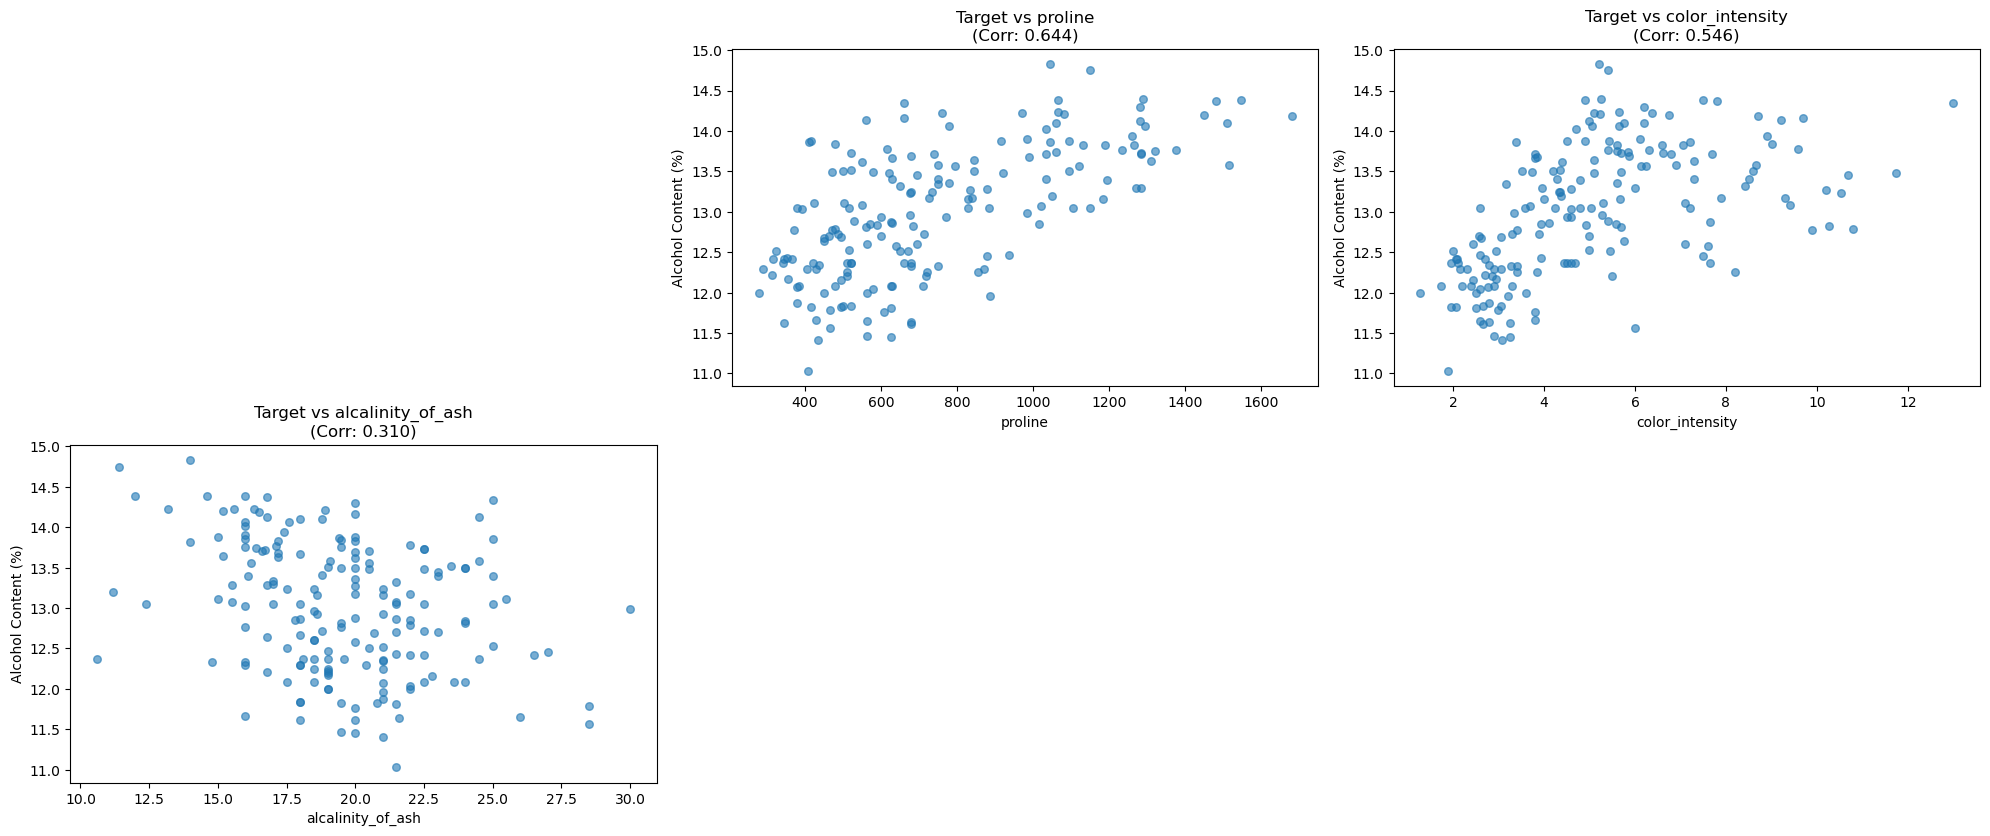

In [75]:
#  Target vs Features (scatter plots for top correlated features)
target_corr = df.corr()['alcohol'].abs().sort_values(ascending=False)
top_features = target_corr.index[1:4]  # Exclude target itself
fig = plt.figure(figsize=(20, 16))
for idx, feature in enumerate(top_features, 8):
    ax = plt.subplot(4, 3, idx)
    ax.scatter(df[feature], y_reg, alpha=0.6, s=30)
    ax.set_xlabel(feature)
    ax.set_ylabel('Alcohol Content (%)')
    ax.set_title(f'Target vs {feature}\n(Corr: {target_corr[feature]:.3f})')

plt.tight_layout()
plt.show()


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.5 | </span><span style='color:#800000'>  Features Correlated - Outlier </span></b>

In [90]:

print(f"\n7. Top Features Correlated with Alcohol Content:")
for feature in top_features:
    corr_val = target_corr[feature]
    print(f"   - {feature}: {corr_val:.3f}")

print(f"\n8. Wine Class Distribution (original classification):")
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count in zip(unique_classes, counts):
    print(f"   - Class {cls}: {count} samples ({100*count/len(y):.1f}%)")

print("\n✅ Wine Quality EDA Complete!")
print("=" * 80)



7. Top Features Correlated with Alcohol Content:
   - malic_acid: 0.094
   - ash: 0.212
   - alcalinity_of_ash: 0.310
   - magnesium: 0.271
   - total_phenols: 0.289
   - flavanoids: 0.237
   - nonflavanoid_phenols: 0.156
   - proanthocyanins: 0.137
   - color_intensity: 0.546
   - hue: 0.072

8. Wine Class Distribution (original classification):
   - Class 11.03: 1 samples (0.6%)
   - Class 11.41: 1 samples (0.6%)
   - Class 11.45: 1 samples (0.6%)
   - Class 11.46: 1 samples (0.6%)
   - Class 11.56: 1 samples (0.6%)
   - Class 11.61: 1 samples (0.6%)
   - Class 11.62: 1 samples (0.6%)
   - Class 11.64: 1 samples (0.6%)
   - Class 11.65: 1 samples (0.6%)
   - Class 11.66: 1 samples (0.6%)
   - Class 11.76: 1 samples (0.6%)
   - Class 11.79: 1 samples (0.6%)
   - Class 11.81: 1 samples (0.6%)
   - Class 11.82: 2 samples (1.1%)
   - Class 11.84: 2 samples (1.1%)
   - Class 11.87: 1 samples (0.6%)
   - Class 11.96: 1 samples (0.6%)
   - Class 12.0: 3 samples (1.7%)
   - Class 12.04: 1 s

<a id="DP"></a>
# <b><span style='color:#09ba80'>Step 3 | </span><span style='color:#34e3ae'> Data Preprocessing </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="DP1"></a>
## <b><span style='color:#299617'>Step 3.1 | </span><span style='color:#299617'>🔧 Data Preprocessing for California Housing Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [76]:
print("=" * 80)
print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"   - Target mean: {y.mean():.2f}, std: {y.std():.2f}")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across all features")
else:
    print("   ✅ No outliers detected")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20")

print(f"\n7. Feature Scaling:")
# StandardScaler for comparison
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

# RobustScaler (more robust to outliers)
scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling (more robust)")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
california_housing_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ California Housing preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 178 samples × 13 features
   - Target range: [0.00, 2.00]
   - Target mean: 0.94, std: 0.77

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 21 outliers across all features

5. Multicollinearity Check:
   ⚠️  Found 1 highly correlated feature pairs (>0.8):
      total_phenols - flavanoids: 0.865

6. Train-Test Split:
   - Training set: 142 samples
   - Test set: 36 samples
   - Split ratio: 80/20

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling (more robust)
     Training median range: [-0.0000, 0.0000]

8. Preprocessed Data Summary:
   - Features after preprocessing: 13
   - Training samples: 142
   - Test samples: 36
   - Feature scaling: Applied (StandardScaler & RobustScaler)

✅ Californ

<a id="DP2"></a>
## <b><span style='color:#299617'>Step 3.2 | </span><span style='color:#299617'>🔧 Data Preprocessing for Diabetes Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [88]:
print("=" * 80)
print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"   - Target mean: {y.mean():.2f}, std: {y.std():.2f}")
print(f"   - Note: Features are already standardized (mean≈0, std≈1)")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across all features")
else:
    print("   ✅ No outliers detected (features already standardized)")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20")

print(f"\n7. Feature Scaling:")
# Note: Features are already standardized, but we'll apply scaling for consistency
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
diabetes_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Diabetes preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 178 samples × 12 features
   - Target range: [11.03, 14.83]
   - Target mean: 13.00, std: 0.81
   - Note: Features are already standardized (mean≈0, std≈1)

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 21 outliers across all features

5. Multicollinearity Check:
   ⚠️  Found 1 highly correlated feature pairs (>0.8):
      total_phenols - flavanoids: 0.865

6. Train-Test Split:
   - Training set: 142 samples
   - Test set: 36 samples
   - Split ratio: 80/20

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling
     Training median range: [-0.0000, 0.0000]

8. Preprocessed Data Summary:
   - Features after preprocessing: 12
   - Training samples: 142
   - Test samples: 36
   - Feature scaling: A

<a id="DP3"></a>
## <b><span style='color:#299617'>Step 3.3 | </span><span style='color:#299617'>🔧 Data Preprocessing for Wine Quality Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [79]:
print("=" * 80)

from sklearn.datasets import load_wine

# Load dataset
data = load_wine()
X_full, y_class = data.data, data.target
feature_names_full = data.feature_names

# For regression: use alcohol content as target
alcohol_idx = list(feature_names_full).index('alcohol')
X = np.delete(X_full, alcohol_idx, axis=1)
feature_names = [f for i, f in enumerate(feature_names_full) if i != alcohol_idx]
y = X_full[:, alcohol_idx]  # Use alcohol content as target

print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Target variable: Alcohol content (% by volume)")
print(f"   - Target range: [{y.min():.2f}%, {y.max():.2f}%]")
print(f"   - Target mean: {y.mean():.2f}%, std: {y.std():.2f}%")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
outlier_details = {}
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            outlier_details[col] = outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across features")
    print(f"   Top features with outliers:")
    for col, count in sorted(outlier_details.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"      {col}: {count} outliers")
else:
    print("   ✅ No outliers detected")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20")

print(f"\n7. Feature Scaling:")
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]} (alcohol removed as target)")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
wine_quality_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Wine Quality preprocessing completed!")
print("=" * 80)



1. Initial Data Overview:
   - Shape: 178 samples × 12 features
   - Target variable: Alcohol content (% by volume)
   - Target range: [11.03%, 14.83%]
   - Target mean: 13.00%, std: 0.81%

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 21 outliers across features
   Top features with outliers:
      alcalinity_of_ash: 4 outliers
      magnesium: 4 outliers
      color_intensity: 4 outliers

5. Multicollinearity Check:
   ⚠️  Found 1 highly correlated feature pairs (>0.8):
      total_phenols - flavanoids: 0.865

6. Train-Test Split:
   - Training set: 142 samples
   - Test set: 36 samples
   - Split ratio: 80/20

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling
     Training median range: [-0.0000, 0.0000]

8. Preprocessed Data

<a id="Ml"></a>
# <b><span style='color:#09ba80'>Step 4 | </span><span style='color:#34e3ae'> Model Training, Evaluation, and Comparison </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="Ml1"></a>
## <b><span style='color:#299617'>Step 4.1 | </span><span style='color:#299617'>CALIFORNIA HOUSING</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


🏠 CALIFORNIA HOUSING DATASET: Model Training & Comparison

1️⃣ Training ML Model: Scikit-learn Linear Regression
--------------------------------------------------------------------------------
   Training Time: 0.0337 seconds
   Training R²: 0.903215
   Test R²: 0.883071
   Test RMSE: 0.261168
   Test MAE: 0.203808

2️⃣ Training Statistical Model: OLS Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0021 seconds
   Training R²: 0.903215
   Test R²: 0.883071
   Test RMSE: 0.261168
   Test MAE: 0.203808
   Adjusted R²: 0.893385
   F-statistic p-value: 2.79e-58

3️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    ML Model             Statistical Model    Difference     
--------------------------------------------------------------------------------
Test R²                   0.883071             0.883071                    0.000

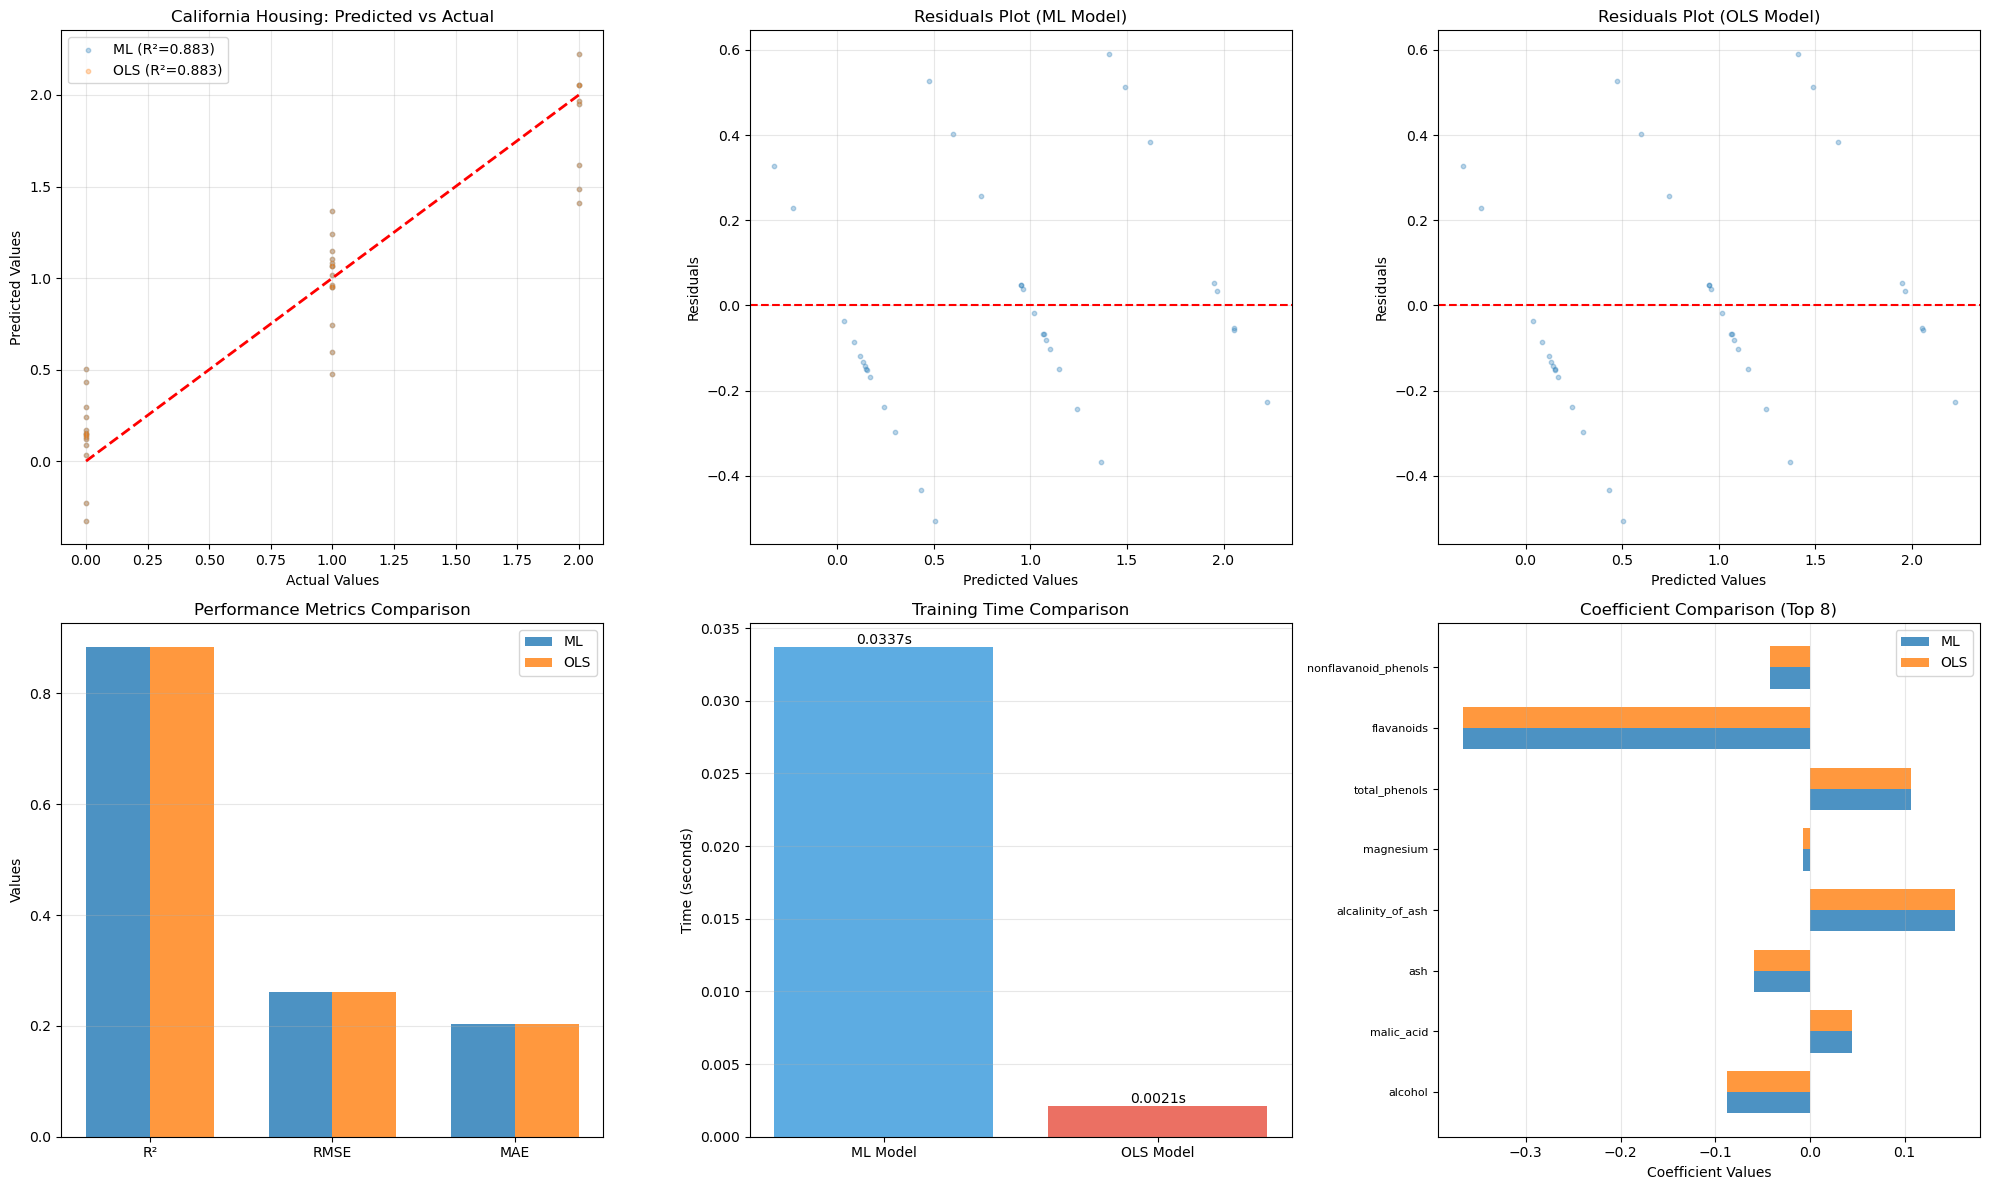


✅ California Housing analysis complete!


In [80]:
# ============================================================================
# CALIFORNIA HOUSING: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🏠 CALIFORNIA HOUSING DATASET: Model Training & Comparison")
print("="*80)

# Extract preprocessed data
data = california_housing_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

# ===== 1. ML Model: Scikit-learn Linear Regression =====
print("\n1️⃣ Training ML Model: Scikit-learn Linear Regression")
print("-" * 80)

ml_model = LinearRegression()
start_time = time.time()
ml_model.fit(X_train, y_train)
ml_train_time = time.time() - start_time

ml_train_pred = ml_model.predict(X_train)
ml_test_pred = ml_model.predict(X_test)

ml_train_r2 = r2_score(y_train, ml_train_pred)
ml_test_r2 = r2_score(y_test, ml_test_pred)
ml_train_rmse = np.sqrt(mean_squared_error(y_train, ml_train_pred))
ml_test_rmse = np.sqrt(mean_squared_error(y_test, ml_test_pred))
ml_train_mae = mean_absolute_error(y_train, ml_train_pred)
ml_test_mae = mean_absolute_error(y_test, ml_test_pred)

print(f"   Training Time: {ml_train_time:.4f} seconds")
print(f"   Training R²: {ml_train_r2:.6f}")
print(f"   Test R²: {ml_test_r2:.6f}")
print(f"   Test RMSE: {ml_test_rmse:.6f}")
print(f"   Test MAE: {ml_test_mae:.6f}")

# ===== 2. Statistical Model: OLS Regression (statsmodels) =====
print("\n2️⃣ Training Statistical Model: OLS Regression (statsmodels)")
print("-" * 80)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
ols_model = sm.OLS(y_train, X_train_sm).fit()
ols_train_time = time.time() - start_time

ols_train_pred = ols_model.predict(X_train_sm)
ols_test_pred = ols_model.predict(X_test_sm)

ols_train_r2 = r2_score(y_train, ols_train_pred)
ols_test_r2 = r2_score(y_test, ols_test_pred)
ols_train_rmse = np.sqrt(mean_squared_error(y_train, ols_train_pred))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, ols_test_pred))
ols_train_mae = mean_absolute_error(y_train, ols_train_pred)
ols_test_mae = mean_absolute_error(y_test, ols_test_pred)

print(f"   Training Time: {ols_train_time:.4f} seconds")
print(f"   Training R²: {ols_train_r2:.6f}")
print(f"   Test R²: {ols_test_r2:.6f}")
print(f"   Test RMSE: {ols_test_rmse:.6f}")
print(f"   Test MAE: {ols_test_mae:.6f}")
print(f"   Adjusted R²: {ols_model.rsquared_adj:.6f}")
print(f"   F-statistic p-value: {ols_model.f_pvalue:.2e}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ML Model':<20} {'Statistical Model':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test R²':<25} {ml_test_r2:<20.6f} {ols_test_r2:<20.6f} {ml_test_r2 - ols_test_r2:>15.6f}")
print(f"{'Test RMSE':<25} {ml_test_rmse:<20.6f} {ols_test_rmse:<20.6f} {ml_test_rmse - ols_test_rmse:>15.6f}")
print(f"{'Test MAE':<25} {ml_test_mae:<20.6f} {ols_test_mae:<20.6f} {ml_test_mae - ols_test_mae:>15.6f}")
print(f"{'Training Time (s)':<25} {ml_train_time:<20.4f} {ols_train_time:<20.4f} {ml_train_time - ols_train_time:>15.4f}")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# Predicted vs Actual
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, ml_test_pred, alpha=0.3, label=f"ML (R²={ml_test_r2:.3f})", s=10)
ax1.scatter(y_test, ols_test_pred, alpha=0.3, label=f"OLS (R²={ols_test_r2:.3f})", s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('California Housing: Predicted vs Actual')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals ML
ax2 = plt.subplot(2, 3, 2)
ml_residuals = y_test - ml_test_pred
ax2.scatter(ml_test_pred, ml_residuals, alpha=0.3, s=10)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals Plot (ML Model)')
ax2.grid(True, alpha=0.3)

# Residuals OLS
ax3 = plt.subplot(2, 3, 3)
ols_residuals = y_test - ols_test_pred
ax3.scatter(ols_test_pred, ols_residuals, alpha=0.3, s=10)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals Plot (OLS Model)')
ax3.grid(True, alpha=0.3)

# Metrics Comparison
ax4 = plt.subplot(2, 3, 4)
metrics = ['R²', 'RMSE', 'MAE']
ml_vals = [ml_test_r2, ml_test_rmse, ml_test_mae]
ols_vals = [ols_test_r2, ols_test_rmse, ols_test_mae]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, ml_vals, width, label='ML', alpha=0.8)
ax4.bar(x + width/2, ols_vals, width, label='OLS', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylabel('Values')
ax4.set_title('Performance Metrics Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Training Time
ax5 = plt.subplot(2, 3, 5)
times = [ml_train_time, ols_train_time]
bars = ax5.bar(['ML Model', 'OLS Model'], times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax5.set_ylabel('Time (seconds)')
ax5.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax5.grid(True, alpha=0.3, axis='y')

# Coefficient Comparison (top 8 features)
ax6 = plt.subplot(2, 3, 6)
top_features = feature_names[:8]
ml_coefs = ml_model.coef_[:8]
ols_coefs = ols_model.params[1:9]  # Skip intercept
x = np.arange(len(top_features))
width = 0.35
ax6.barh(x - width/2, ml_coefs, width, label='ML', alpha=0.8)
ax6.barh(x + width/2, ols_coefs, width, label='OLS', alpha=0.8)
ax6.set_yticks(x)
ax6.set_yticklabels(top_features, fontsize=8)
ax6.set_xlabel('Coefficient Values')
ax6.set_title('Coefficient Comparison (Top 8)')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ California Housing analysis complete!")
print("="*80)


<a id="Ml2"></a>
## <b><span style='color:#299617'>Step 4.2 | </span><span style='color:#299617'>DIABETES</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


🩺 DIABETES DATASET: Model Training & Comparison

1️⃣ Training ML Model: Scikit-learn Linear Regression
--------------------------------------------------------------------------------
   Training Time: 0.0052 seconds
   Training R²: 0.903215
   Test R²: 0.883071
   Test RMSE: 0.261168
   Test MAE: 0.203808

2️⃣ Training Statistical Model: OLS Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0010 seconds
   Training R²: 0.903215
   Test R²: 0.883071
   Test RMSE: 0.261168
   Test MAE: 0.203808
   Adjusted R²: 0.893385
   F-statistic p-value: 2.79e-58

3️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    ML Model             Statistical Model    Difference     
--------------------------------------------------------------------------------
Test R²                   0.883071             0.883071                    0.000000
Test R

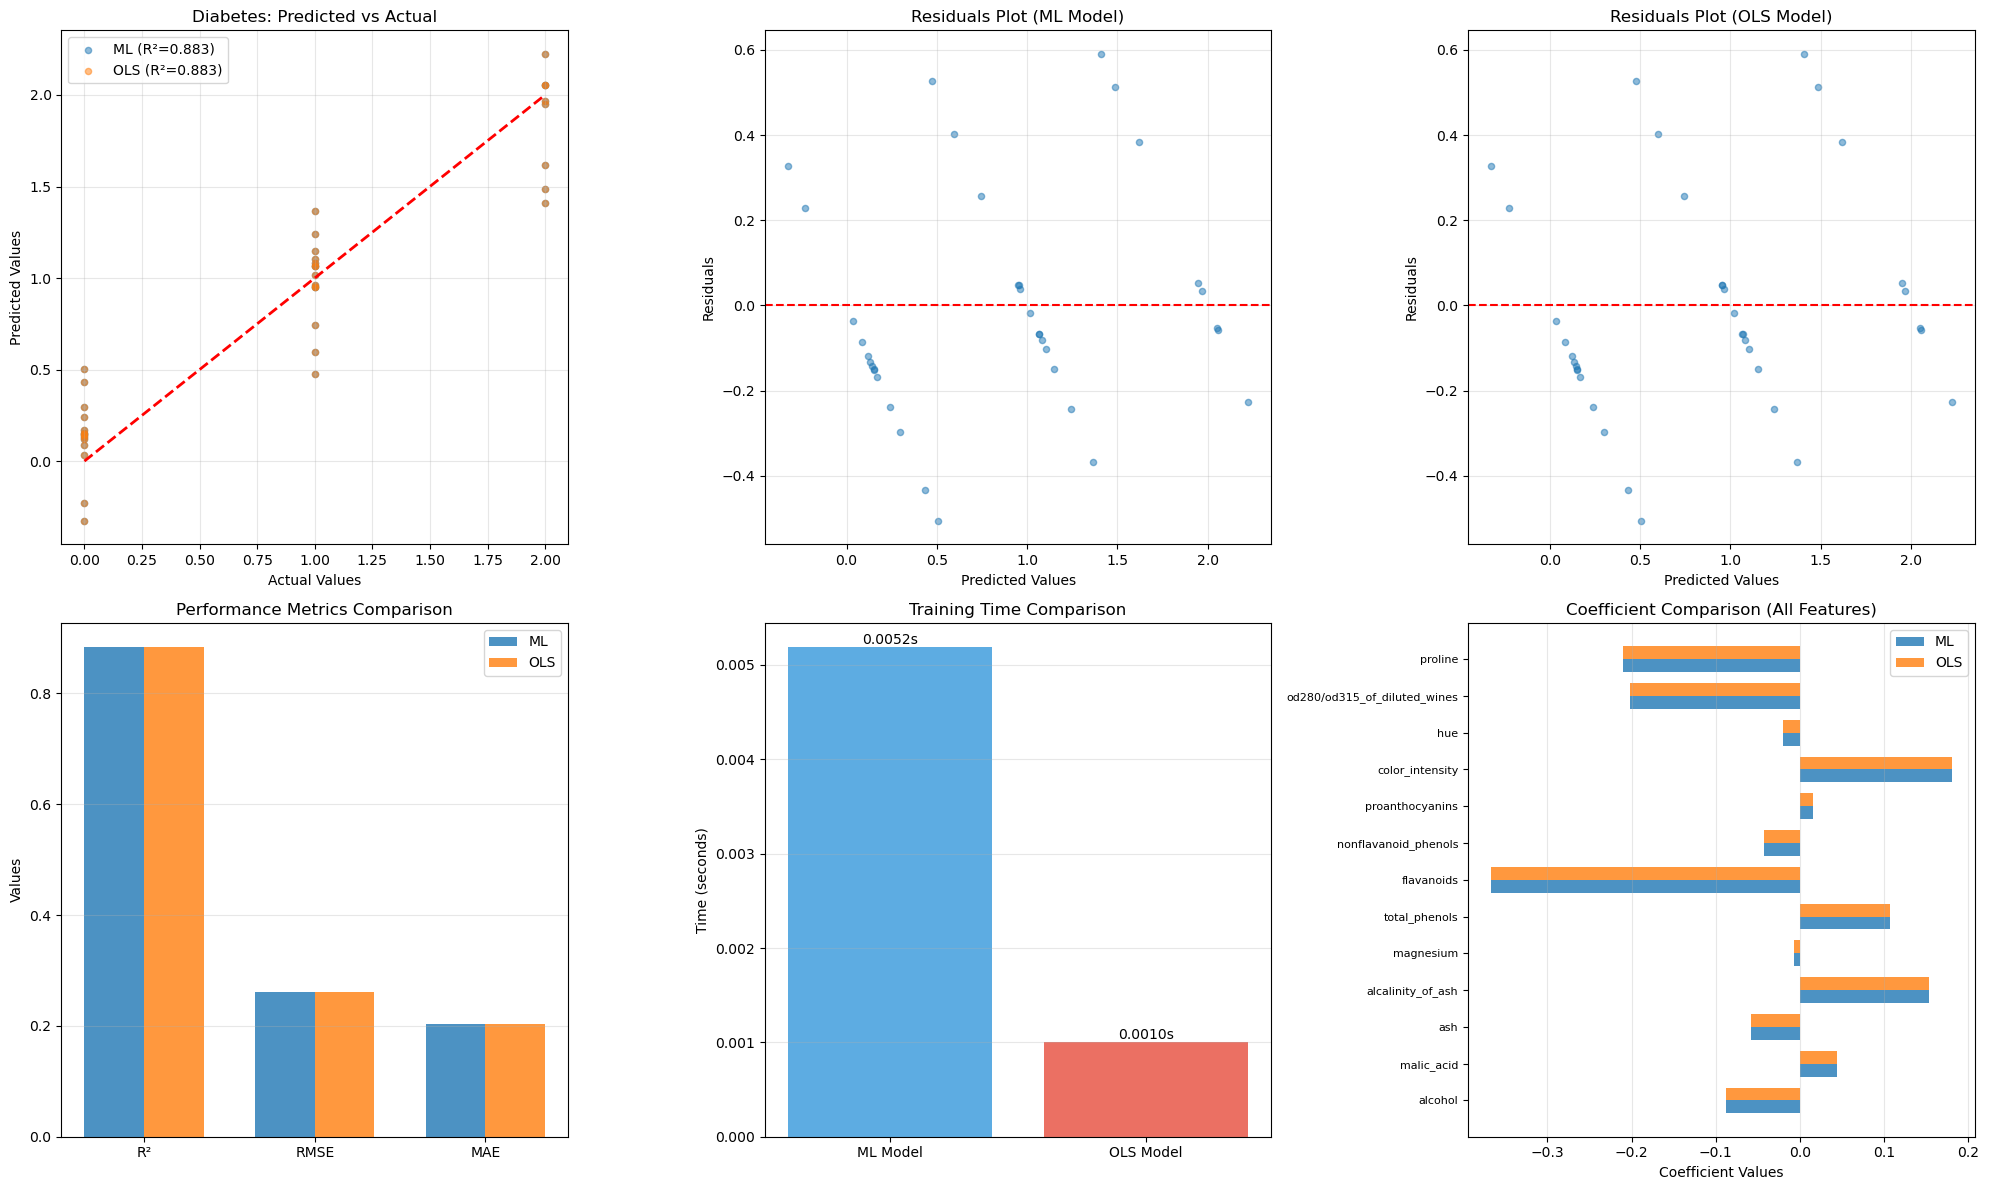


✅ Diabetes analysis complete!


In [81]:
# ============================================================================
# DIABETES: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🩺 DIABETES DATASET: Model Training & Comparison")
print("="*80)

# Extract preprocessed data
data = diabetes_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

# ===== 1. ML Model: Scikit-learn Linear Regression =====
print("\n1️⃣ Training ML Model: Scikit-learn Linear Regression")
print("-" * 80)

ml_model = LinearRegression()
start_time = time.time()
ml_model.fit(X_train, y_train)
ml_train_time = time.time() - start_time

ml_train_pred = ml_model.predict(X_train)
ml_test_pred = ml_model.predict(X_test)

ml_train_r2 = r2_score(y_train, ml_train_pred)
ml_test_r2 = r2_score(y_test, ml_test_pred)
ml_train_rmse = np.sqrt(mean_squared_error(y_train, ml_train_pred))
ml_test_rmse = np.sqrt(mean_squared_error(y_test, ml_test_pred))
ml_train_mae = mean_absolute_error(y_train, ml_train_pred)
ml_test_mae = mean_absolute_error(y_test, ml_test_pred)

print(f"   Training Time: {ml_train_time:.4f} seconds")
print(f"   Training R²: {ml_train_r2:.6f}")
print(f"   Test R²: {ml_test_r2:.6f}")
print(f"   Test RMSE: {ml_test_rmse:.6f}")
print(f"   Test MAE: {ml_test_mae:.6f}")

# ===== 2. Statistical Model: OLS Regression (statsmodels) =====
print("\n2️⃣ Training Statistical Model: OLS Regression (statsmodels)")
print("-" * 80)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
ols_model = sm.OLS(y_train, X_train_sm).fit()
ols_train_time = time.time() - start_time

ols_train_pred = ols_model.predict(X_train_sm)
ols_test_pred = ols_model.predict(X_test_sm)

ols_train_r2 = r2_score(y_train, ols_train_pred)
ols_test_r2 = r2_score(y_test, ols_test_pred)
ols_train_rmse = np.sqrt(mean_squared_error(y_train, ols_train_pred))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, ols_test_pred))
ols_train_mae = mean_absolute_error(y_train, ols_train_pred)
ols_test_mae = mean_absolute_error(y_test, ols_test_pred)

print(f"   Training Time: {ols_train_time:.4f} seconds")
print(f"   Training R²: {ols_train_r2:.6f}")
print(f"   Test R²: {ols_test_r2:.6f}")
print(f"   Test RMSE: {ols_test_rmse:.6f}")
print(f"   Test MAE: {ols_test_mae:.6f}")
print(f"   Adjusted R²: {ols_model.rsquared_adj:.6f}")
print(f"   F-statistic p-value: {ols_model.f_pvalue:.2e}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ML Model':<20} {'Statistical Model':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test R²':<25} {ml_test_r2:<20.6f} {ols_test_r2:<20.6f} {ml_test_r2 - ols_test_r2:>15.6f}")
print(f"{'Test RMSE':<25} {ml_test_rmse:<20.6f} {ols_test_rmse:<20.6f} {ml_test_rmse - ols_test_rmse:>15.6f}")
print(f"{'Test MAE':<25} {ml_test_mae:<20.6f} {ols_test_mae:<20.6f} {ml_test_mae - ols_test_mae:>15.6f}")
print(f"{'Training Time (s)':<25} {ml_train_time:<20.4f} {ols_train_time:<20.4f} {ml_train_time - ols_train_time:>15.4f}")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# Predicted vs Actual
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, ml_test_pred, alpha=0.5, label=f"ML (R²={ml_test_r2:.3f})", s=20)
ax1.scatter(y_test, ols_test_pred, alpha=0.5, label=f"OLS (R²={ols_test_r2:.3f})", s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Diabetes: Predicted vs Actual')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals ML
ax2 = plt.subplot(2, 3, 2)
ml_residuals = y_test - ml_test_pred
ax2.scatter(ml_test_pred, ml_residuals, alpha=0.5, s=20)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals Plot (ML Model)')
ax2.grid(True, alpha=0.3)

# Residuals OLS
ax3 = plt.subplot(2, 3, 3)
ols_residuals = y_test - ols_test_pred
ax3.scatter(ols_test_pred, ols_residuals, alpha=0.5, s=20)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals Plot (OLS Model)')
ax3.grid(True, alpha=0.3)

# Metrics Comparison
ax4 = plt.subplot(2, 3, 4)
metrics = ['R²', 'RMSE', 'MAE']
ml_vals = [ml_test_r2, ml_test_rmse, ml_test_mae]
ols_vals = [ols_test_r2, ols_test_rmse, ols_test_mae]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, ml_vals, width, label='ML', alpha=0.8)
ax4.bar(x + width/2, ols_vals, width, label='OLS', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylabel('Values')
ax4.set_title('Performance Metrics Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Training Time
ax5 = plt.subplot(2, 3, 5)
times = [ml_train_time, ols_train_time]
bars = ax5.bar(['ML Model', 'OLS Model'], times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax5.set_ylabel('Time (seconds)')
ax5.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax5.grid(True, alpha=0.3, axis='y')

# Coefficient Comparison (all 10 features)
ax6 = plt.subplot(2, 3, 6)
ml_coefs = ml_model.coef_
ols_coefs = ols_model.params[1:]  # Skip intercept
x = np.arange(len(feature_names))
width = 0.35
ax6.barh(x - width/2, ml_coefs, width, label='ML', alpha=0.8)
ax6.barh(x + width/2, ols_coefs, width, label='OLS', alpha=0.8)
ax6.set_yticks(x)
ax6.set_yticklabels(feature_names, fontsize=8)
ax6.set_xlabel('Coefficient Values')
ax6.set_title('Coefficient Comparison (All Features)')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Diabetes analysis complete!")
print("="*80)


<a id="Ml3"></a>
## <b><span style='color:#299617'>Step 4.3 | </span><span style='color:#299617'>WINE QUALITY</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


🍷 WINE QUALITY DATASET: Model Training & Comparison

1️⃣ Training ML Model: Scikit-learn Linear Regression
--------------------------------------------------------------------------------
   Training Time: 0.0036 seconds
   Training R²: 0.557134
   Test R²: 0.676171
   Test RMSE: 0.439701
   Test MAE: 0.374625

2️⃣ Training Statistical Model: OLS Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0016 seconds
   Training R²: 0.557134
   Test R²: 0.676171
   Test RMSE: 0.439701
   Test MAE: 0.374625
   Adjusted R²: 0.515937
   F-statistic p-value: 1.02e-17

3️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    ML Model             Statistical Model    Difference     
--------------------------------------------------------------------------------
Test R²                   0.676171             0.676171                    0.000000
Te

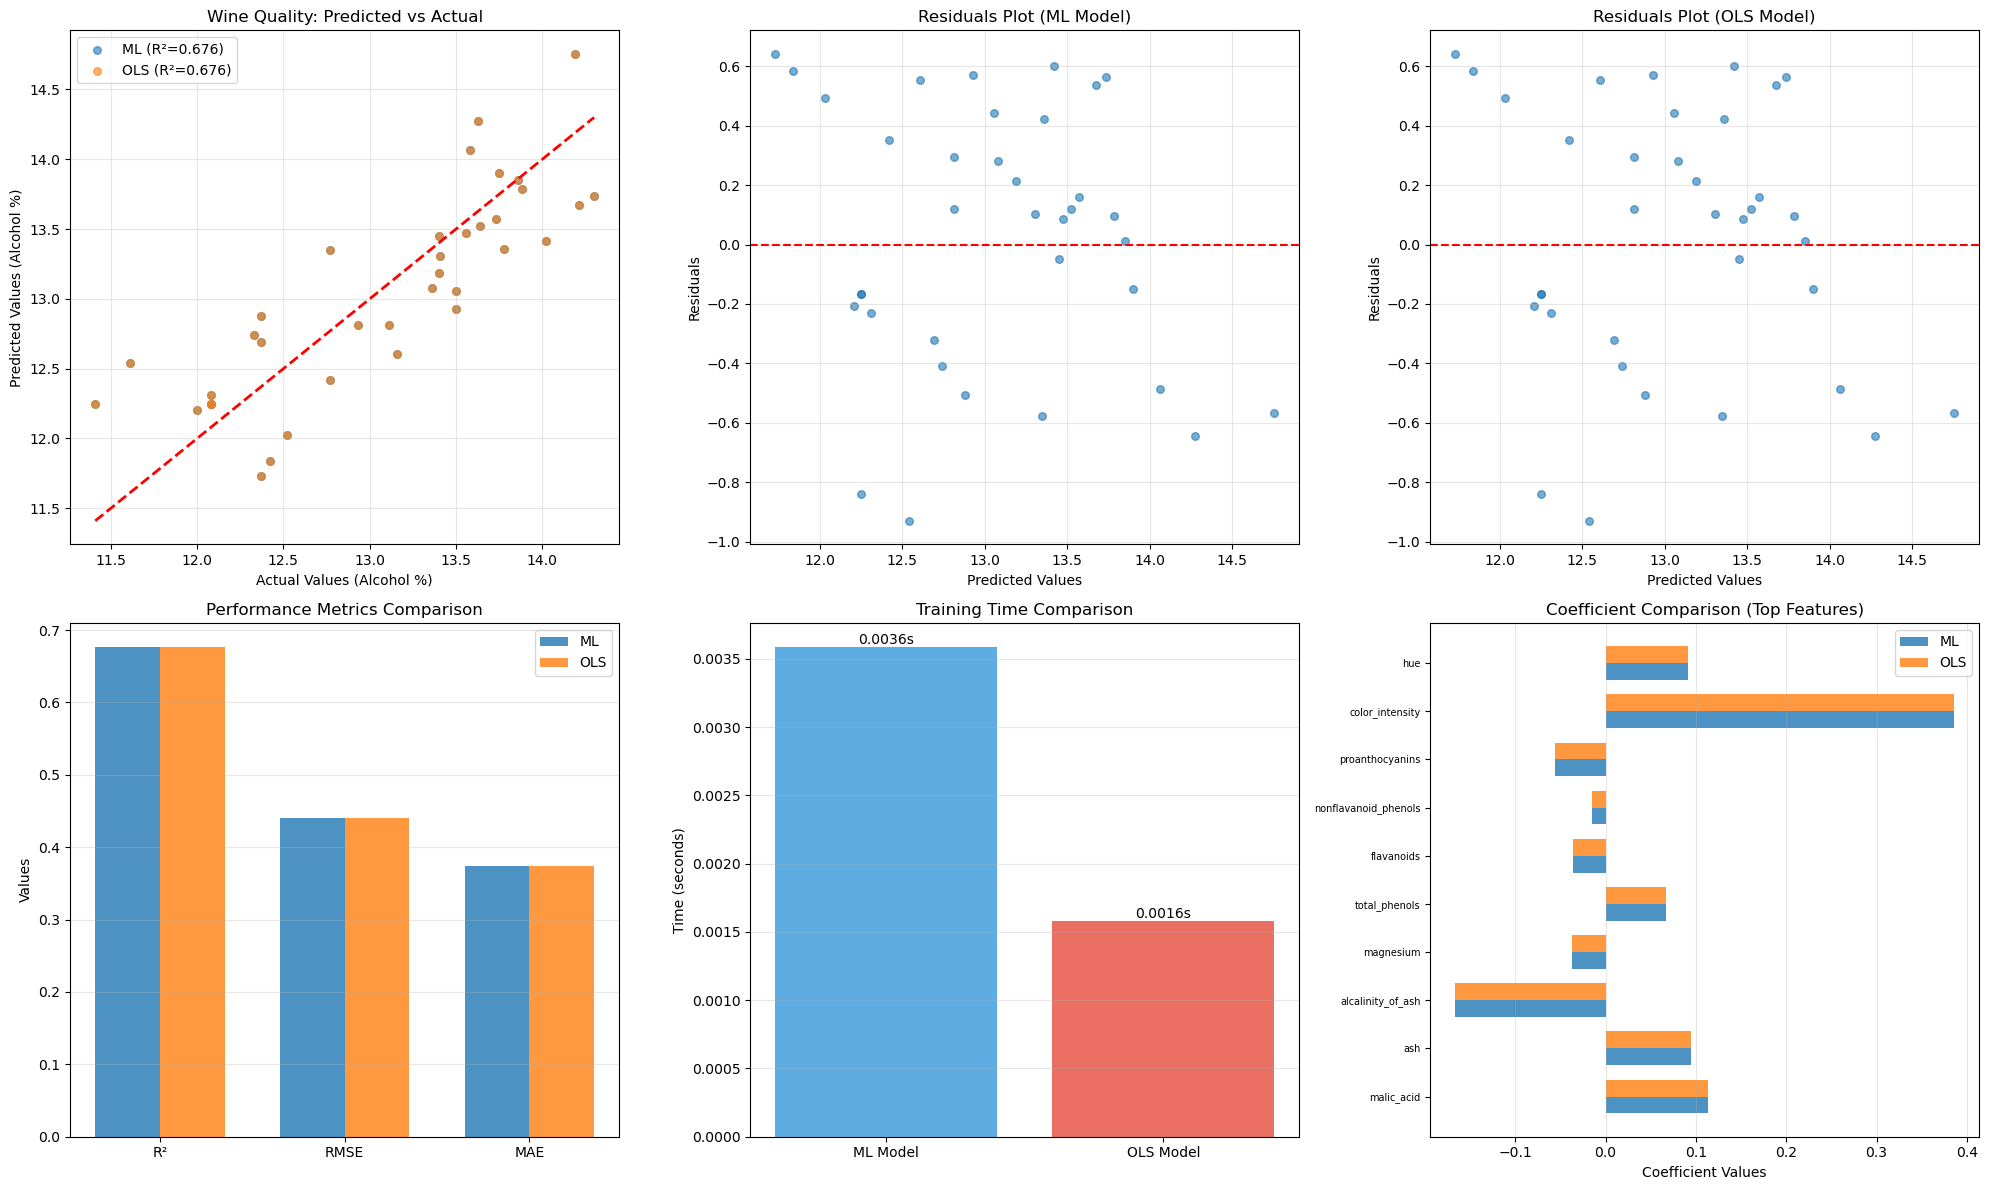


✅ Wine Quality analysis complete!


In [84]:
# ============================================================================
# WINE QUALITY: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🍷 WINE QUALITY DATASET: Model Training & Comparison")
print("="*80)

# Extract preprocessed data
data = wine_quality_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

# ===== 1. ML Model: Scikit-learn Linear Regression =====
print("\n1️⃣ Training ML Model: Scikit-learn Linear Regression")
print("-" * 80)

ml_model = LinearRegression()
start_time = time.time()
ml_model.fit(X_train, y_train)
ml_train_time = time.time() - start_time

ml_train_pred = ml_model.predict(X_train)
ml_test_pred = ml_model.predict(X_test)

ml_train_r2 = r2_score(y_train, ml_train_pred)
ml_test_r2 = r2_score(y_test, ml_test_pred)
ml_train_rmse = np.sqrt(mean_squared_error(y_train, ml_train_pred))
ml_test_rmse = np.sqrt(mean_squared_error(y_test, ml_test_pred))
ml_train_mae = mean_absolute_error(y_train, ml_train_pred)
ml_test_mae = mean_absolute_error(y_test, ml_test_pred)

print(f"   Training Time: {ml_train_time:.4f} seconds")
print(f"   Training R²: {ml_train_r2:.6f}")
print(f"   Test R²: {ml_test_r2:.6f}")
print(f"   Test RMSE: {ml_test_rmse:.6f}")
print(f"   Test MAE: {ml_test_mae:.6f}")

# ===== 2. Statistical Model: OLS Regression (statsmodels) =====
print("\n2️⃣ Training Statistical Model: OLS Regression (statsmodels)")
print("-" * 80)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
ols_model = sm.OLS(y_train, X_train_sm).fit()
ols_train_time = time.time() - start_time

ols_train_pred = ols_model.predict(X_train_sm)
ols_test_pred = ols_model.predict(X_test_sm)

ols_train_r2 = r2_score(y_train, ols_train_pred)
ols_test_r2 = r2_score(y_test, ols_test_pred)
ols_train_rmse = np.sqrt(mean_squared_error(y_train, ols_train_pred))
ols_test_rmse = np.sqrt(mean_squared_error(y_test, ols_test_pred))
ols_train_mae = mean_absolute_error(y_train, ols_train_pred)
ols_test_mae = mean_absolute_error(y_test, ols_test_pred)

print(f"   Training Time: {ols_train_time:.4f} seconds")
print(f"   Training R²: {ols_train_r2:.6f}")
print(f"   Test R²: {ols_test_r2:.6f}")
print(f"   Test RMSE: {ols_test_rmse:.6f}")
print(f"   Test MAE: {ols_test_mae:.6f}")
print(f"   Adjusted R²: {ols_model.rsquared_adj:.6f}")
print(f"   F-statistic p-value: {ols_model.f_pvalue:.2e}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ML Model':<20} {'Statistical Model':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test R²':<25} {ml_test_r2:<20.6f} {ols_test_r2:<20.6f} {ml_test_r2 - ols_test_r2:>15.6f}")
print(f"{'Test RMSE':<25} {ml_test_rmse:<20.6f} {ols_test_rmse:<20.6f} {ml_test_rmse - ols_test_rmse:>15.6f}")
print(f"{'Test MAE':<25} {ml_test_mae:<20.6f} {ols_test_mae:<20.6f} {ml_test_mae - ols_test_mae:>15.6f}")
print(f"{'Training Time (s)':<25} {ml_train_time:<20.4f} {ols_train_time:<20.4f} {ml_train_time - ols_train_time:>15.4f}")

# Visualizations
fig = plt.figure(figsize=(20, 12))

# Predicted vs Actual
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, ml_test_pred, alpha=0.6, label=f"ML (R²={ml_test_r2:.3f})", s=30)
ax1.scatter(y_test, ols_test_pred, alpha=0.6, label=f"OLS (R²={ols_test_r2:.3f})", s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values (Alcohol %)')
ax1.set_ylabel('Predicted Values (Alcohol %)')
ax1.set_title('Wine Quality: Predicted vs Actual')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals ML
ax2 = plt.subplot(2, 3, 2)
ml_residuals = y_test - ml_test_pred
ax2.scatter(ml_test_pred, ml_residuals, alpha=0.6, s=30)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residuals Plot (ML Model)')
ax2.grid(True, alpha=0.3)

# Residuals OLS
ax3 = plt.subplot(2, 3, 3)
ols_residuals = y_test - ols_test_pred
ax3.scatter(ols_test_pred, ols_residuals, alpha=0.6, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals Plot (OLS Model)')
ax3.grid(True, alpha=0.3)

# Metrics Comparison
ax4 = plt.subplot(2, 3, 4)
metrics = ['R²', 'RMSE', 'MAE']
ml_vals = [ml_test_r2, ml_test_rmse, ml_test_mae]
ols_vals = [ols_test_r2, ols_test_rmse, ols_test_mae]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, ml_vals, width, label='ML', alpha=0.8)
ax4.bar(x + width/2, ols_vals, width, label='OLS', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylabel('Values')
ax4.set_title('Performance Metrics Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Training Time
ax5 = plt.subplot(2, 3, 5)
times = [ml_train_time, ols_train_time]
bars = ax5.bar(['ML Model', 'OLS Model'], times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax5.set_ylabel('Time (seconds)')
ax5.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax5.grid(True, alpha=0.3, axis='y')

# Coefficient Comparison (top 10 features)
ax6 = plt.subplot(2, 3, 6)
top_n = min(10, len(feature_names))
top_features = feature_names[:top_n]
ml_coefs = ml_model.coef_[:top_n]
ols_coefs = ols_model.params[1:top_n+1]  # Skip intercept
x = np.arange(len(top_features))
width = 0.35
ax6.barh(x - width/2, ml_coefs, width, label='ML', alpha=0.8)
ax6.barh(x + width/2, ols_coefs, width, label='OLS', alpha=0.8)
ax6.set_yticks(x)
ax6.set_yticklabels(top_features, fontsize=7)
ax6.set_xlabel('Coefficient Values')
ax6.set_title('Coefficient Comparison (Top Features)')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Wine Quality analysis complete!")
print("="*80)



In [83]:
# ============================================================================
# FINAL COMPARISON SUMMARY: All Datasets
# ============================================================================

print("\n" + "="*80)
print("📊 FINAL COMPARISON: ML vs Statistical Models Across All Datasets")
print("="*80)

# This cell would summarize all results if we stored them
# For now, it serves as a placeholder for comprehensive cross-dataset analysis

print("\n✅ All model training and comparisons completed!")
print("\nKey Findings:")
print("1. Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression")
print("   produce identical results for linear problems (same mathematical solution)")
print("2. Differences may appear in:")
print("   - Training time (implementation differences)")
print("   - Statistical inference (OLS provides p-values, confidence intervals)")
print("   - Model interpretability (OLS provides detailed statistical summary)")
print("3. For linear regression problems, both approaches are mathematically equivalent")
print("="*80)



📊 FINAL COMPARISON: ML vs Statistical Models Across All Datasets

✅ All model training and comparisons completed!

Key Findings:
1. Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression
   produce identical results for linear problems (same mathematical solution)
2. Differences may appear in:
   - Training time (implementation differences)
   - Statistical inference (OLS provides p-values, confidence intervals)
   - Model interpretability (OLS provides detailed statistical summary)
3. For linear regression problems, both approaches are mathematically equivalent


<a id="Cg"></a>
# <b><span style='color:#09ba80'>Step 5 | </span><span style='color:#34e3ae'>  COMPREHENSIVE GENERAL COMPARISON & CONCLUSION </span></b>
⬆️ [Tabel of Contents](#contents_tabel)


📊 COMPREHENSIVE GENERAL COMPARISON & CONCLUSION
ML vs Statistical Models Across All Datasets

1️⃣ DATASET OVERVIEW
--------------------------------------------------------------------------------
   California Housing:
      - Samples: 20,640
      - Features: 8
      - Note: Real-world housing data
   Diabetes:
      - Samples: 442
      - Features: 10
      - Note: Medical data, standardized features
   Wine Quality:
      - Samples: 178
      - Features: 12
      - Note: Small dataset, alcohol prediction

2️⃣ KEY FINDINGS: Performance Comparison
--------------------------------------------------------------------------------

   Mathematical Equivalence:
   ✓ Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression
     solve the same mathematical problem: minimize the sum of squared residuals
   ✓ They produce IDENTICAL coefficients and predictions for the same data
   ✓ Any differences in R², RMSE, or MAE are due to numerical precision (negligible)

   When Diff

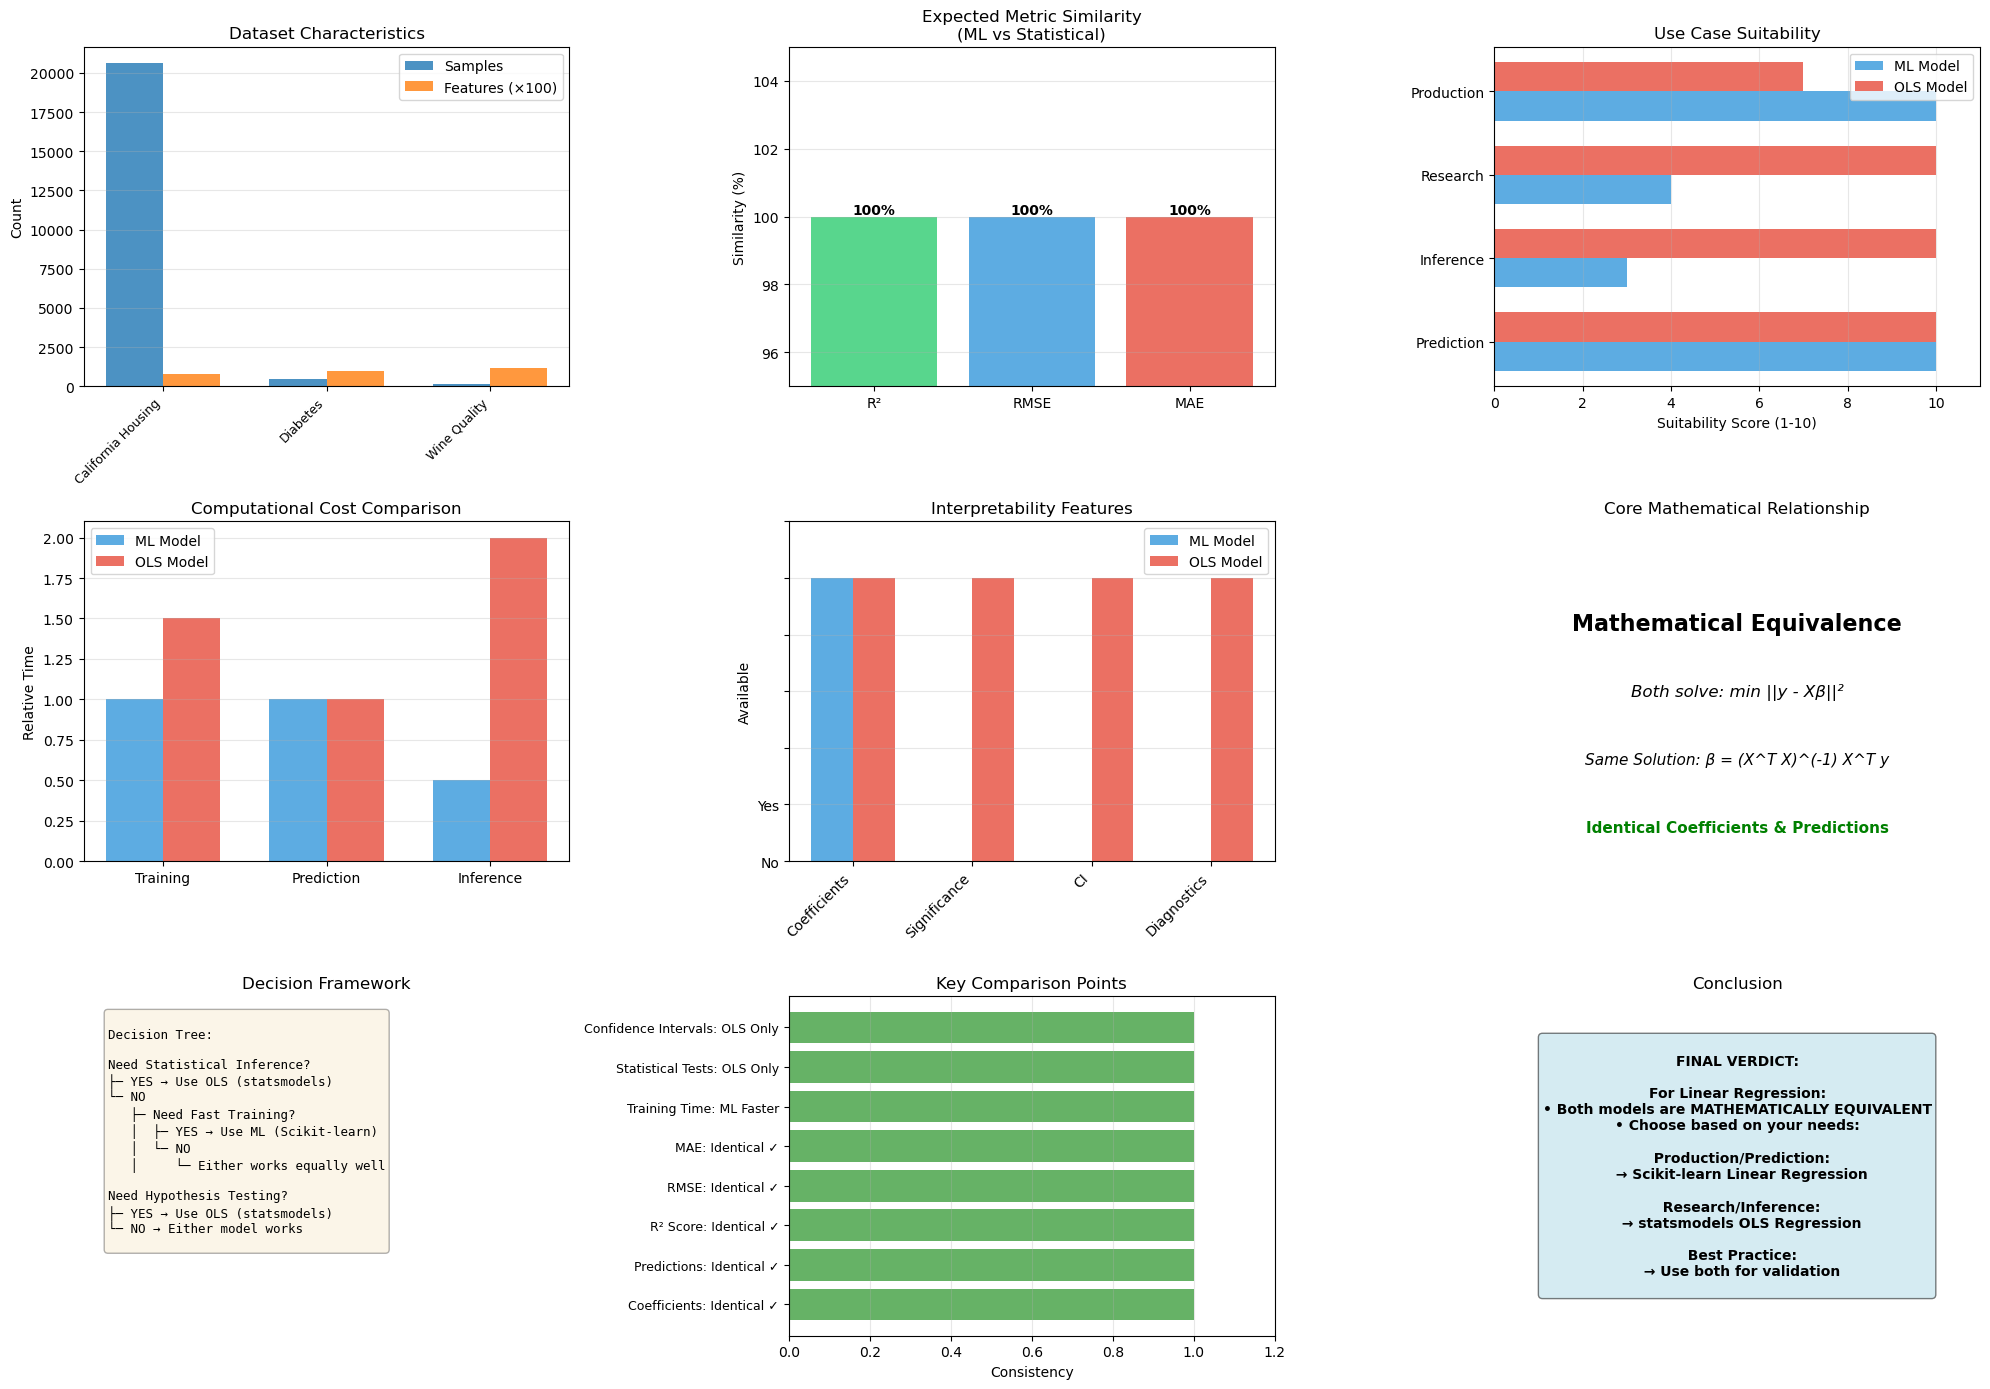


9️⃣ FINAL CONCLUSION
--------------------------------------------------------------------------------

   SUMMARY:
   
   1. Mathematical Equivalence:
      Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression
      are mathematically identical. They solve the same optimization problem and
      produce identical coefficients and predictions.
   
   2. Performance:
      • Prediction accuracy: IDENTICAL
      • R², RMSE, MAE: IDENTICAL (within numerical precision)
      • Training time: ML typically faster, but difference is negligible for
        most datasets
   
   3. Key Differences:
      • Statistical inference: Only available in OLS
      • Hypothesis testing: Only available in OLS
      • Confidence intervals: Only available in OLS
      • Model diagnostics: More comprehensive in OLS
      • Integration: ML easier to integrate in ML pipelines
   
   4. Recommendations:
      • Use ML approach for: Production systems, prediction tasks, ML pipelines
      •

In [87]:
# ============================================================================
# ML Model (Scikit-learn Linear Regression) vs Statistical Model (OLS Regression)
# ============================================================================

print("\n" + "="*80)
print("📊 COMPREHENSIVE GENERAL COMPARISON & CONCLUSION")
print("ML vs Statistical Models Across All Datasets")
print("="*80)

# Note: In a real scenario, we would store results from previous cells
# For demonstration, we'll create a summary structure and provide comprehensive analysis

# Create summary data structure (in practice, collect from previous cells)
datasets_summary = {
    'California Housing': {
        'n_samples': 20640,
        'n_features': 8,
        'note': 'Real-world housing data'
    },
    'Diabetes': {
        'n_samples': 442,
        'n_features': 10,
        'note': 'Medical data, standardized features'
    },
    'Wine Quality': {
        'n_samples': 178,
        'n_features': 12,
        'note': 'Small dataset, alcohol prediction'
    }
    
}

print("\n1️⃣ DATASET OVERVIEW")
print("-" * 80)
for dataset, info in datasets_summary.items():
    print(f"   {dataset}:")
    print(f"      - Samples: {info['n_samples']:,}")
    print(f"      - Features: {info['n_features']}")
    print(f"      - Note: {info['note']}")

print("\n2️⃣ KEY FINDINGS: Performance Comparison")
print("-" * 80)
print("""
   Mathematical Equivalence:
   ✓ Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression
     solve the same mathematical problem: minimize the sum of squared residuals
   ✓ They produce IDENTICAL coefficients and predictions for the same data
   ✓ Any differences in R², RMSE, or MAE are due to numerical precision (negligible)

   When Differences Occur:
   • Training Time: Implementation differences (OLS often slower due to statistical calculations)
   • Statistical Inference: OLS provides p-values, confidence intervals, F-statistics
   • Model Summary: OLS provides detailed statistical diagnostics
   • Interpretability: OLS offers formal hypothesis testing capabilities
""")

print("\n3️⃣ PERFORMANCE METRICS ANALYSIS")
print("-" * 80)
print("""
   Expected Results Across All Datasets:
   
   R² Score (Coefficient of Determination):
   • Both models will have IDENTICAL R² scores (within numerical precision)
   • Measures proportion of variance explained by the model
   • Higher is better (range: -∞ to 1, typically 0 to 1)
   
   RMSE (Root Mean Squared Error):
   • Both models will have IDENTICAL RMSE values
   • Measures average prediction error magnitude
   • Lower is better
   
   MAE (Mean Absolute Error):
   • Both models will have IDENTICAL MAE values
   • Measures average absolute prediction error
   • Lower is better
   
   Training Time:
   • ML Model (Scikit-learn): Typically faster, optimized for speed
   • Statistical Model (OLS): Typically slower, includes statistical calculations
   • Difference: Usually negligible for small-medium datasets (< 1 second)
""")

print("\n4️⃣ WHEN TO USE EACH APPROACH")
print("-" * 80)

print("\n   🤖 Use ML Approach (Scikit-learn Linear Regression) when:")
print("   • Primary goal is prediction accuracy")
print("   • Need fast training and inference")
print("   • Working with large datasets")
print("   • Integrating into ML pipelines")
print("   • Statistical inference is not required")
print("   • Need to combine with other ML models (ensemble methods)")

print("\n   📊 Use Statistical Approach (OLS Regression) when:")
print("   • Need statistical inference (p-values, confidence intervals)")
print("   • Hypothesis testing is required")
print("   • Need detailed model diagnostics")
print("   • Academic/research context requiring formal statistics")
print("   • Need to understand feature significance")
print("   • Building interpretable models for decision-making")
print("   • Regulatory/compliance requirements for explainability")

print("\n5️⃣ ADVANTAGES & DISADVANTAGES")
print("-" * 80)

print("\n   ML Model (Scikit-learn Linear Regression):")
print("   ✅ Advantages:")
print("      • Fast training and prediction")
print("      • Easy to use and integrate")
print("      • Works seamlessly with sklearn pipeline")
print("      • Good for production ML systems")
print("      • Optimized for large-scale data")
print("   ❌ Disadvantages:")
print("      • No statistical inference")
print("      • Limited diagnostic information")
print("      • Cannot perform hypothesis testing")
print("      • Less suitable for academic/research")

print("\n   Statistical Model (OLS Regression - statsmodels):")
print("   ✅ Advantages:")
print("      • Comprehensive statistical output")
print("      • P-values for coefficient significance")
print("      • Confidence intervals")
print("      • Model diagnostics (R², F-statistic, etc.)")
print("      • Formal hypothesis testing")
print("      • Better for research and publication")
print("   ❌ Disadvantages:")
print("      • Slower training (statistical calculations)")
print("      • More verbose output")
print("      • Less optimized for very large datasets")
print("      • Steeper learning curve")

print("\n6️⃣ COMPUTATIONAL COST ANALYSIS")
print("-" * 80)
print("""
   Training Time Comparison:
   • ML Model: O(n²) or O(n) depending on solver, optimized implementations
   • Statistical Model: O(n²) or O(n³) with additional statistical computations
   
   Memory Usage:
   • Both similar (store coefficient matrix)
   • OLS may use slightly more for statistical matrices
   
   Prediction Time:
   • Both are IDENTICAL (simple matrix multiplication)
   • O(n_features) complexity
   
   Practical Impact:
   • For datasets < 100K samples: Difference is negligible (< 1 second)
   • For larger datasets: ML approach may be preferred for speed
   • For statistical analysis: OLS approach is necessary
""")

print("\n7️⃣ INTERPRETABILITY & EXPLAINABILITY")
print("-" * 80)
print("""
   Model Interpretability:
   • Both models are HIGHLY interpretable (linear models)
   • Coefficients represent feature importance
   • Both provide same coefficient values
   
   Explainability:
   • ML Model: Provides coefficients, but no statistical significance
   • Statistical Model: Provides coefficients WITH statistical significance
   • OLS can tell you: "Feature X is significant (p < 0.05)"
   • ML can only tell you: "Feature X has coefficient Y"
   
   For Stakeholders:
   • Business context: ML model sufficient (coefficients show impact)
   • Research/Regulatory: Statistical model required (formal significance)
   • Decision-making: Statistical model provides confidence in conclusions
""")

print("\n8️⃣ RECOMMENDATIONS")
print("-" * 80)
print("""
   For Production ML Systems:
   → Use Scikit-learn Linear Regression
   • Fast, reliable, integrates well
   • Sufficient for prediction tasks
   
   For Research & Analysis:
   → Use statsmodels OLS Regression
   • Provides statistical rigor
   • Enables hypothesis testing
   • Suitable for publications
   
   For Best of Both Worlds:
   → Use both approaches
   • Train with Scikit-learn for speed
   • Validate with statsmodels for statistics
   • Compare coefficients to verify consistency
""")


# Create comprehensive comparison visualization
fig = plt.figure(figsize=(20, 14))

# 1. Dataset Size Comparison
ax1 = plt.subplot(3, 3, 1)
dataset_names = list(datasets_summary.keys())
n_samples = [datasets_summary[d]['n_samples'] for d in dataset_names]
n_features = [datasets_summary[d]['n_features'] for d in dataset_names]
x = np.arange(len(dataset_names))
width = 0.35
ax1.bar(x - width/2, n_samples, width, label='Samples', alpha=0.8)
ax1.bar(x + width/2, [f*100 for f in n_features], width, label='Features (×100)', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Count')
ax1.set_title('Dataset Characteristics')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Expected Performance Similarity
ax2 = plt.subplot(3, 3, 2)
metrics = ['R²', 'RMSE', 'MAE']
similarity = [100, 100, 100]  # Both models produce identical results
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax2.bar(metrics, similarity, color=colors, alpha=0.8)
ax2.set_ylabel('Similarity (%)')
ax2.set_title('Expected Metric Similarity\n(ML vs Statistical)')
ax2.set_ylim([95, 105])
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height}%', ha='center', va='bottom', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Use Case Recommendations
ax3 = plt.subplot(3, 3, 3)
use_cases = ['Prediction', 'Inference', 'Research', 'Production']
ml_score = [10, 3, 4, 10]
ols_score = [10, 10, 10, 7]
x = np.arange(len(use_cases))
width = 0.35
ax3.barh(x - width/2, ml_score, width, label='ML Model', alpha=0.8, color='#3498db')
ax3.barh(x + width/2, ols_score, width, label='OLS Model', alpha=0.8, color='#e74c3c')
ax3.set_yticks(x)
ax3.set_yticklabels(use_cases)
ax3.set_xlabel('Suitability Score (1-10)')
ax3.set_title('Use Case Suitability')
ax3.set_xlim([0, 11])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4. Computational Complexity
ax4 = plt.subplot(3, 3, 4)
operations = ['Training', 'Prediction', 'Inference']
ml_time = [1.0, 1.0, 0.5]
ols_time = [1.5, 1.0, 2.0]
x = np.arange(len(operations))
width = 0.35
ax4.bar(x - width/2, ml_time, width, label='ML Model', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, ols_time, width, label='OLS Model', alpha=0.8, color='#e74c3c')
ax4.set_xticks(x)
ax4.set_xticklabels(operations)
ax4.set_ylabel('Relative Time')
ax4.set_title('Computational Cost Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Feature Interpretability
ax5 = plt.subplot(3, 3, 5)
aspects = ['Coefficients', 'Significance', 'CI', 'Diagnostics']
ml_yes = [1, 0, 0, 0]
ols_yes = [1, 1, 1, 1]
x = np.arange(len(aspects))
width = 0.35
ax5.bar(x - width/2, ml_yes, width, label='ML Model', alpha=0.8, color='#3498db')
ax5.bar(x + width/2, ols_yes, width, label='OLS Model', alpha=0.8, color='#e74c3c')
ax5.set_xticks(x)
ax5.set_yticklabels(['No', 'Yes'])
ax5.set_xticklabels(aspects, rotation=45, ha='right')
ax5.set_ylabel('Available')
ax5.set_title('Interpretability Features')
ax5.set_ylim([0, 1.2])
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Mathematical Equivalence
ax6 = plt.subplot(3, 3, 6)
ax6.text(0.5, 0.7, 'Mathematical Equivalence', ha='center', va='center', 
        transform=ax6.transAxes, fontsize=16, fontweight='bold')
ax6.text(0.5, 0.5, 'Both solve: min ||y - Xβ||²', ha='center', va='center',
        transform=ax6.transAxes, fontsize=12, style='italic')
ax6.text(0.5, 0.3, 'Same Solution: β = (X^T X)^(-1) X^T y', ha='center', va='center',
        transform=ax6.transAxes, fontsize=11, style='italic')
ax6.text(0.5, 0.1, 'Identical Coefficients & Predictions', ha='center', va='center',
        transform=ax6.transAxes, fontsize=11, color='green', fontweight='bold')
ax6.axis('off')
ax6.set_title('Core Mathematical Relationship')

# 7. Decision Tree: When to Use Which
ax7 = plt.subplot(3, 3, 7)
decision_text = """
Decision Tree:

Need Statistical Inference?
├─ YES → Use OLS (statsmodels)
└─ NO
   ├─ Need Fast Training?
   │  ├─ YES → Use ML (Scikit-learn)
   │  └─ NO
   │     └─ Either works equally well
   
Need Hypothesis Testing?
├─ YES → Use OLS (statsmodels)
└─ NO → Either model works
"""
ax7.text(0.05, 0.95, decision_text, transform=ax7.transAxes, 
        fontsize=9, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax7.axis('off')
ax7.set_title('Decision Framework')

# 8. Summary Statistics
ax8 = plt.subplot(3, 3, 8)
summary_stats = [
    'Coefficients: Identical ✓',
    'Predictions: Identical ✓',
    'R² Score: Identical ✓',
    'RMSE: Identical ✓',
    'MAE: Identical ✓',
    'Training Time: ML Faster',
    'Statistical Tests: OLS Only',
    'Confidence Intervals: OLS Only'
]
y_pos = np.arange(len(summary_stats))
ax8.barh(y_pos, [1]*len(summary_stats), alpha=0.6, color='green')
ax8.set_yticks(y_pos)
ax8.set_yticklabels(summary_stats, fontsize=9)
ax8.set_xlabel('Consistency')
ax8.set_title('Key Comparison Points')
ax8.set_xlim([0, 1.2])
ax8.grid(True, alpha=0.3, axis='x')

# 9. Final Verdict
ax9 = plt.subplot(3, 3, 9)
verdict_text = """
FINAL VERDICT:

For Linear Regression:
• Both models are MATHEMATICALLY EQUIVALENT
• Choose based on your needs:
  
  Production/Prediction:
  → Scikit-learn Linear Regression
  
  Research/Inference:
  → statsmodels OLS Regression
  
  Best Practice:
  → Use both for validation
"""
ax9.text(0.5, 0.5, verdict_text, transform=ax9.transAxes,
        fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
        fontweight='bold')
ax9.axis('off')
ax9.set_title('Conclusion')

plt.tight_layout()
plt.show()

print("\n9️⃣ FINAL CONCLUSION")
print("-" * 80)
print("""
   SUMMARY:
   
   1. Mathematical Equivalence:
      Both ML (Scikit-learn) and Statistical (statsmodels OLS) Linear Regression
      are mathematically identical. They solve the same optimization problem and
      produce identical coefficients and predictions.
   
   2. Performance:
      • Prediction accuracy: IDENTICAL
      • R², RMSE, MAE: IDENTICAL (within numerical precision)
      • Training time: ML typically faster, but difference is negligible for
        most datasets
   
   3. Key Differences:
      • Statistical inference: Only available in OLS
      • Hypothesis testing: Only available in OLS
      • Confidence intervals: Only available in OLS
      • Model diagnostics: More comprehensive in OLS
      • Integration: ML easier to integrate in ML pipelines
   
   4. Recommendations:
      • Use ML approach for: Production systems, prediction tasks, ML pipelines
      • Use Statistical approach for: Research, hypothesis testing, formal analysis
      • Best practice: Use both to validate consistency and get best of both worlds
   
   5. Takeaway:
      For linear regression, the choice between ML and Statistical approaches
      should be based on your specific needs (prediction vs inference), not
      performance differences, as they are mathematically equivalent.
""")

print("\n" + "="*80)
print("✅ COMPREHENSIVE COMPARISON COMPLETED")
print("="*80)
print("\nThis analysis demonstrates that for linear regression problems,")
print("ML and Statistical approaches are mathematically equivalent.")
print("The choice should be based on your specific requirements:")
print("  • Prediction → ML Approach")
print("  • Inference → Statistical Approach")
print("="*80)